# Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?

## Etapa 1 — Carregamento e reconhecimento da base

Carregamento da base **State of Data Brazil 2024–202S5** reconhecimento inicial dos dados. Vamos entender o tamanho da base, os tipos de dados, a quantidade de valores ausentes e quais colunas são relevantes para responder à pergunta central:

<br>

***Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?***

<br>

A base original será mantida no DataFrame `df`, sem alterações. Em seguida, criaremos um DataFrame separado chamado `df_subset`, contendo apenas as colunas renomeadas que serão usadas na análise. Isso evita trabalhar com mais de 400 colunas desnecessárias e torna o notebook mais claro e fácil de exportar para o dashboard.

### 1.1 Importação das bibliotecas e carregamento do CSV

Montagem do google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports de bibliotecas e carregamento do CSV

In [2]:
# Bibliotecas principais do projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais básicas
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

# Caminho do arquivo CSV
CAMINHO_CSV = "/content/drive/MyDrive/Trabalho Final - Análise Avançada de Dados/data/raw/Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv"

# Carregamento da base
try:
    df = pd.read_csv(CAMINHO_CSV, sep=None, engine="python", encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(CAMINHO_CSV, sep=None, engine="python", encoding="latin1")

# Visualização inicial
df.head()

,0.a_token,0.d_data/hora_envio,1.a_idade,1.a.1_faixa_idade,1.b_genero,1.c_cor/raca/etnia,1.d_pcd,1.e_experiencia_profissional_prejudicada,1.e.1_Não acredito que minha experiência profissional seja afetada,"1.e.2_Sim, devido a minha Cor/Raça/Etnia","1.e.3_Sim, devido a minha identidade de gênero","1.e.4_Sim, devido ao fato de ser PCD",1.i.1_uf_onde_mora,1.f.1_Quantidade de oportunidades de emprego/vagas recebidas,1.f.2_Senioridade das vagas recebidas em relação à sua experiência,1.f.3_Aprovação em processos seletivos/entrevistas,1.f.4_Oportunidades de progressão de carreira,1.f.5_Velocidade de progressão de carreira,1.f.6_Nível de cobrança no trabalho/Stress no trabalho,1.f.7_Atenção dada pelas pessoas diante das minhas opiniões e ideias,"1.f.8_Relação com outras pessoas da empresa, em momentos de trabalho","1.f.9_Relação com outras pessoas da empresa, em momentos de integração e outros momentos fora do trabalho",1.i.2_regiao_onde_mora,1.f_aspectos_prejudicados,1.k.1_uf_de_origem,1.k.2_regiao_de_origem,1.g_vive_no_brasil,1.h_pais_onde_mora,1.i_estado_onde_mora,1.j_vive_no_estado_de_formacao,1.k_estado_de_origem,1.l_nivel_de_ensino,1.m_área_de_formação,2.a_situação_de_trabalho,2.b_setor,2.c_numero_de_funcionarios,2.d_atua_como_gestor,2.e_cargo_como_gestor,2.f_cargo_atual,2.g_nivel,2.h_faixa_salarial,2.i_tempo_de_experiencia_em_dados,2.j_tempo_de_experiencia_em_ti,2.k_satisfeito_atualmente,2.l.1_Remuneração/Salário,2.l.2_Benefícios,2.l.3_Propósito do trabalho e da empresa,2.l.4_Flexibilidade de trabalho remoto,2.l.5_Ambiente e clima de trabalho,2.l.6_Oportunidade de aprendizado e trabalhar com referências,2.l.7_Oportunidades de crescimento,2.l.8_Maturidade da empresa em termos de tecnologia e dados,2.l.9_Relação com os gestores e líderes,2.l.10_Reputação que a empresa tem no mercado,2.l.11_Gostaria de trabalhar em outra área,2.l_motivo_insatisfacao,2.m_participou_de_entrevistas_ultimos_6m,2.n_planos_de_mudar_de_emprego_6m,2.o_criterios_para_escolha_de_emprego,2.o.1_Remuneração/Salário,...,7.d.4_Utilizando API's para extrair dados e complementar minhas análises.,"7.d.5_Realizando experimentos e estudos utilizando metodologias estatísticas como teste de hipótese, modelos de regressão etc.","7.d.6_Desenvolvendo/cuidando da manutenção de ETL's utilizando tecnologias como Talend, Pentaho, Airflow, Dataflow etc.","7.d.7_Atuando na modelagem dos dados, com o objetivo de criar conjuntos de dados como Data Warehouses, Data Marts, Datasets etc.",7.d.8_Desenvolvendo/cuidando da manutenção de planilhas para atender as áreas de negócio.,"7.d.9_Utilizando ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises de dados.",7.d.10_Nenhuma das opções listadas refletem meu dia a dia.,8.a_rotina_como_ds,"8.a.1_Estudos Ad-hoc com o objetivo de confirmar hipóteses, realizar modelos preditivos, forecasts, análise de cluster para resolver problemas pontuais e responder perguntas das áreas de negócio.",8.a.2_Sou responsável pela coleta e limpeza dos dados que uso para análise e modelagem.,"8.a.3_Sou responsável por entrar em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.",8.a.4_Desenvolvo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).,"8.a.5_Sou responsável por colocar modelos em produção, criar os pipelines de dados, APIs de consumo e monitoramento.","8.a.6_Cuido da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.","8.a.7_Realizo construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc","8.a.8_Utilizo ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises.","8.a.9_Crio e dou manutenção em ETLs, DAGs e automações de pipelines de dados.",8.a.10_Crio e gerencio soluções de Feature Store e cultura de MLOps.,"8.a.11_Sou responsável por criar e manter a infra que meus modelos e

### 1.2 Reconhecimento inicial da base

In [3]:
# Quantidade de linhas e colunas
print(f"A base possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

# Tipos de dados
df.info()

A base possui 5217 linhas e 403 colunas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Columns: 403 entries, 0.a_token to 8.d.12_Treinando e aplicando LLM's para solucionar problemas de negócio.
dtypes: bool(1), float64(323), int64(1), object(78)
memory usage: 16.0+ MB


In [4]:
# Primeira visão dos valores ausentes
nulos = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("qtd_nulos")
)

nulos["perc_nulos"] = (nulos["qtd_nulos"] / len(df) * 100).round(2)

nulos.head(30)

,qtd_nulos,perc_nulos
1.h_pais_onde_mora,5078,97.34
5.b_oportunidade_buscada,4931,94.52
5.d_experiencia_em_processos_seletivos,4928,94.46
5.c_tempo_em_busca_de_oportunidade,4927,94.44
5.a_objetivo_na_area_de_dados,4676,89.63
6.g_ferramentas_de_qualidade_de_dados_(dia_a_dia),4657,89.27
6.f_tecnologia_data_warehouse,4491,86.08
6.d_tecnologia_data_lake,4482,85.91
"8.d.11_Criando e mantendo a infra que meus modelos e soluções rodam (clusters, servidores, API, containers, etc.)",4444,85.18
8.c_tecnologias_ds,4444,85.18


In [5]:
# Exibir toda as colunas numeradas
for i, coluna in enumerate(df.columns):
    print(f"{i}: {coluna}")

0: 0.a_token
1: 0.d_data/hora_envio
2: 1.a_idade
3: 1.a.1_faixa_idade
4: 1.b_genero
5: 1.c_cor/raca/etnia
6: 1.d_pcd
7: 1.e_experiencia_profissional_prejudicada
8: 1.e.1_Não acredito que minha experiência profissional seja afetada
9: 1.e.2_Sim, devido a minha Cor/Raça/Etnia
10: 1.e.3_Sim, devido a minha identidade de gênero
11: 1.e.4_Sim, devido ao fato de ser PCD
12: 1.i.1_uf_onde_mora
13: 1.f.1_Quantidade de oportunidades de emprego/vagas recebidas
14: 1.f.2_Senioridade das vagas recebidas em relação à sua experiência
15: 1.f.3_Aprovação em processos seletivos/entrevistas
16: 1.f.4_Oportunidades de progressão de carreira
17: 1.f.5_Velocidade de progressão de carreira
18: 1.f.6_Nível de cobrança no trabalho/Stress no trabalho
19: 1.f.7_Atenção dada pelas pessoas diante das minhas opiniões e ideias
20: 1.f.8_Relação com outras pessoas da empresa, em momentos de trabalho
21: 1.f.9_Relação com outras pessoas da empresa, em momentos de integração e outros momentos fora do trabalho
22: 1.i

### 1.3 Seleção e renomeação das colunas relevantes

Após a leitura do dicionário oficial da base, selecionamos as colunas mais relevantes para responder à pergunta central do trabalho. Usaremos variáveis relacionadas a salário, cargo, senioridade, experiência, formação, localização, perfil demográfico, modelo de trabalho e satisfação.

As colunas foram renomeadas para nomes mais simples e legíveis. Esse processo facilita a leitura do notebook e evita o uso de nomes longos ou codificados.

Colunas que vamos usar na análise:

| Grupo           | Nome original esperado no dicionário        | Nome atualizado      |
| --------------- | ------------------------------------------- | -------------------- |
| Perfil          | Idade                                       | `idade`              |
| Perfil          | Gênero                                      | `genero`             |
| Perfil          | Cor/Raça/Etnia                              | `cor_raca_etnia`     |
| Localização     | UF onde mora                                | `uf`                 |
| Localização     | Região onde mora                            | `regiao`             |
| Formação        | Nível de ensino                             | `nivel_ensino`       |
| Formação        | Área de formação                            | `area_formacao`      |
| Trabalho        | Situação atual de trabalho                  | `situacao_trabalho`  |
| Empresa         | Setor da empresa                            | `setor_empresa`      |
| Empresa         | Número de funcionários / tamanho da empresa | `tamanho_empresa`    |
| Cargo           | Cargo atual                                 | `cargo_atual`        |
| Cargo           | Nível / senioridade                         | `senioridade`        |
| Remuneração     | Faixa salarial                              | `faixa_salarial`     |
| Experiência     | Experiência na área de dados                | `experiencia_dados`  |
| Experiência     | Experiência na área de TI                   | `experiencia_ti`     |
| Trabalho remoto | Modelo de trabalho                          | `modelo_trabalho`    |
| Satisfação      | Satisfação no emprego atual                 | `satisfacao_emprego` |


In [6]:
# Mapeamento final das colunas selecionadas

rename_map = {
    "1.a_idade": "idade",
    "1.b_genero": "genero",
    "1.c_cor/raca/etnia": "cor_raca_etnia",
    "1.i.1_uf_onde_mora": "uf",
    "1.i.2_regiao_onde_mora": "regiao",
    "1.l_nivel_de_ensino": "nivel_ensino",
    "1.m_área_de_formação": "area_formacao",
    "2.a_situação_de_trabalho": "situacao_trabalho",
    "2.b_setor": "setor_empresa",
    "2.c_numero_de_funcionarios": "tamanho_empresa",
    "2.f_cargo_atual": "cargo_atual",
    "2.g_nivel": "senioridade",
    "2.h_faixa_salarial": "faixa_salarial",
    "2.i_tempo_de_experiencia_em_dados": "experiencia_dados",
    "2.j_tempo_de_experiencia_em_ti": "experiencia_ti",
    "2.k_satisfeito_atualmente": "satisfacao_emprego",
    "2.r_modelo_de_trabalho_atual": "modelo_trabalho",
}

# Conferir se todas as colunas existem na base original
colunas_ausentes = [col for col in rename_map.keys() if col not in df.columns]

if len(colunas_ausentes) == 0:
    print("Todas as colunas do mapeamento foram encontradas.")
else:
    print("Colunas não encontradas:")
    for coluna in colunas_ausentes:
        print(coluna)

Todas as colunas do mapeamento foram encontradas.


### 1.4 Criação do df_subset

In [7]:
# Criar uma cópia renomeada sem alterar o df original
df_renomeado = df.rename(columns=rename_map)

# Colunas que serão usadas na análise
colunas_analise = list(rename_map.values())

# Criar o df_subset apenas com as colunas selecionadas
df_subset = df_renomeado[colunas_analise].copy()

print(f"df original: {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"df_subset: {df_subset.shape[0]} linhas e {df_subset.shape[1]} colunas")

df_subset.head()

df original: 5217 linhas e 403 colunas
df_subset: 5217 linhas e 17 colunas


,idade,genero,cor_raca_etnia,uf,regiao,nivel_ensino,area_formacao,situacao_trabalho,setor_empresa,tamanho_empresa,cargo_atual,senioridade,faixa_salarial,experiencia_dados,experiencia_ti,satisfacao_emprego,modelo_trabalho
0,18,Masculino,Branca,RS,Sul,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Marketing,de 101 a 500,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,de 1 a 2 anos,True,Modelo 100% remoto
1,18,Masculino,Branca,SC,Sul,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Finanças ou Bancos,Acima de 3.000,Analista de BI/BI Analyst,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Menos de 1 ano,True,Modelo 100% presencial
2,18,Masculino,Parda,SP,Sudeste,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Indústria,de 501 a 1.000,Outra Opção,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,False,Modelo 100% presencial
3,18,Masculino,Branca,SP,Sudeste,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,de 501 a 1.000,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,True,Modelo híbrido flexível (o funcionário tem lib...
4,18,Masculino,Branca,SP,Sudeste,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,de 1.001 a 3.000,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano,Menos de 1 ano,True,Modelo 100% remoto


In [8]:
# Verificar colunas selecionadas
df_subset.columns.tolist()

['idade',
 'genero',
 'cor_raca_etnia',
 'uf',
 'regiao',
 'nivel_ensino',
 'area_formacao',
 'situacao_trabalho',
 'setor_empresa',
 'tamanho_empresa',
 'cargo_atual',
 'senioridade',
 'faixa_salarial',
 'experiencia_dados',
 'experiencia_ti',
 'satisfacao_emprego',
 'modelo_trabalho']

In [9]:
# Tipos de dados do subset
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   idade               5217 non-null   int64 
 1   genero              5217 non-null   object
 2   cor_raca_etnia      5217 non-null   object
 3   uf                  5075 non-null   object
 4   regiao              5075 non-null   object
 5   nivel_ensino        5217 non-null   object
 6   area_formacao       5123 non-null   object
 7   situacao_trabalho   5217 non-null   object
 8   setor_empresa       4863 non-null   object
 9   tamanho_empresa     4863 non-null   object
 10  cargo_atual         3818 non-null   object
 11  senioridade         3818 non-null   object
 12  faixa_salarial      4863 non-null   object
 13  experiencia_dados   4863 non-null   object
 14  experiencia_ti      4863 non-null   object
 15  satisfacao_emprego  4863 non-null   object
 16  modelo_trabalho     4863

In [10]:
# Valores nulos apenas nas colunas que serão usadas
nulos_subset = (
    df_subset.isna()
             .sum()
             .sort_values(ascending=False)
             .to_frame("qtd_nulos")
)

nulos_subset["perc_nulos"] = (nulos_subset["qtd_nulos"] / len(df_subset) * 100).round(2)

nulos_subset

,qtd_nulos,perc_nulos
senioridade,1399,26.82
cargo_atual,1399,26.82
modelo_trabalho,354,6.79
setor_empresa,354,6.79
satisfacao_emprego,354,6.79
faixa_salarial,354,6.79
tamanho_empresa,354,6.79
experiencia_ti,354,6.79
experiencia_dados,354,6.79
uf,142,2.72


## Etapa 2 — Limpeza e decisões documentadas

Nesta etapa, vamos preparar o `df_subset` para análise estatística.

* A base original informa salário em faixas textuais, o que impede cálculos estatísticos. Por isso, a primeira decisão será converter cada faixa salarial para um ponto médio numérico.

* As categorias de cargo também precisam de preparo, pois profissionais com funções semelhantes ou iguais podem aparecer com nomes diferentes, aqui usaremos uma padronização

* Por fim, vamos tratar valores ausentes.

### 2.1 Conversão da faixa salarial

* A coluna de salário está em formato textual, com faixas como "de R\$4.001 a R\$6.000". Para permitir cálculos estatísticos, cada faixa será convertida para seu ponto médio.

* Essa decisão facilita a análise mas o valor numérico criado é uma aproximação, não o salário exato do respondente, o que aumenta a imprecisão.

* Para faixas abertas, como "acima de R\$40.001", usaremos um valor conservador para não puxar os salários para cima de maneira equivocada.

In [11]:
import re

# Converter a faixa salarial em ponto médio numérico
def converter_faixa_salarial_para_ponto_medio(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).lower().replace(".", "")
    numeros = [int(n) for n in re.findall(r"\d+", texto)]

    if len(numeros) >= 2:
        return np.mean(numeros[:2])

    if len(numeros) == 1 and "menos" in texto:
        return numeros[0] / 2

    if len(numeros) == 1 and ("acima" in texto or "mais" in texto):
        return numeros[0] + 5000

    return np.nan


df_subset["salario_medio"] = df_subset["faixa_salarial"].apply(converter_faixa_salarial_para_ponto_medio)

df_subset[["faixa_salarial", "salario_medio"]].drop_duplicates().sort_values("salario_medio")

,faixa_salarial,salario_medio
1,Menos de R$ 1.000/mês,500.0
0,de R$ 1.001/mês a R$ 2.000/mês,1500.5
11,de R$ 2.001/mês a R$ 3.000/mês,2500.5
9,de R$ 3.001/mês a R$ 4.000/mês,3500.5
14,de R$ 4.001/mês a R$ 6.000/mês,5000.5
6,de R$ 6.001/mês a R$ 8.000/mês,7000.5
73,de R$ 8.001/mês a R$ 12.000/mês,10000.5
118,de R$ 12.001/mês a R$ 16.000/mês,14000.5
343,de R$ 16.001/mês a R$ 20.000/mês,18000.5
288,de R$ 20.001/mês a R$ 25.000/mês,22500.5


### 2.2 Padronização de cargos

A coluna de cargo pode conter nomes diferentes para funções semelhantes. Por exemplo, "Analista de Dados", "Data Analyst" e variações parecidas que representam o mesmo grupo profissional para fins de análise.

Para reduzir ruído, os cargos serão agrupados em categorias mais amplas: Analista de Dados, Cientista de Dados, Engenheiro de Dados, Analista de BI, Engenheiro de Machine Learning, Gestor/Liderança, Outras funções técnicas e Outros. Essa decisão melhora a comparação salarial entre grupos.

In [12]:
def padronizar_cargo(cargo):
    if pd.isna(cargo):
        return np.nan

    texto = str(cargo).lower()

    if ("analista" in texto and "dados" in texto) or "data analyst" in texto:
        return "Analista de Dados"

    if "cientista" in texto or "data scientist" in texto:
        return "Cientista de Dados"

    if ("engenheiro" in texto and "dados" in texto) or "data engineer" in texto:
        return "Engenheiro de Dados"

    if "analytics engineer" in texto:
        return "Analytics Engineer"

    if "machine learning" in texto or "ml engineer" in texto:
        return "Engenheiro de Machine Learning"

    if "bi" in texto or "business intelligence" in texto:
        return "Analista de BI"

    if any(palavra in texto for palavra in ["gestor", "gerente", "coordenador", "head", "lead", "líder", "lider", "manager"]):
        return "Gestor/Liderança"

    if any(palavra in texto for palavra in ["engenheiro", "desenvolvedor", "developer", "arquiteto", "arquiteta"]):
        return "Outras funções técnicas"

    return "Outros"


df_subset["cargo_padronizado"] = df_subset["cargo_atual"].apply(padronizar_cargo)

df_subset[["cargo_atual", "cargo_padronizado"]].drop_duplicates().head(50)

,cargo_atual,cargo_padronizado
0,Analista de Dados/Data Analyst,Analista de Dados
1,Analista de BI/BI Analyst,Analista de BI
2,Outra Opção,Outros
4,Desenvolvedor/ Engenheiro de Software/ Analist...,Outras funções técnicas
5,NaN,NaN
13,Engenheiro de Dados/Data Engineer/Data Architect,Engenheiro de Dados
14,Analytics Engineer,Analytics Engineer
17,Analista de Negócios/Business Analyst,Outros
55,Analista de Suporte/Analista Técnico,Outros
74,Cientista de Dados/Data Scientist,Cientista de Dados


In [13]:
df_subset["cargo_padronizado"].value_counts(dropna=False)

,count
cargo_padronizado,
NaN,1399
Analista de Dados,957
Cientista de Dados,687
Engenheiro de Dados,613
Outros,584
Analista de BI,396
Analytics Engineer,228
Outras funções técnicas,170
Engenheiro de Machine Learning,103


### 2.3 Padronização de senioridade

A senioridade foi transformada em uma variável ordinal para permitir análise estatística. A escala utilizada foi: Júnior = 1, Pleno = 2 e Sênior = 3, uma vez que esses níveis possuem uma ordem natural

Termos ligados a gestão ou liderança não foram classificados como senioridade. Esses casos são tratados na variável `cargo_padronizado`.

In [14]:
def padronizar_senioridade(valor):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).lower()

    if any(palavra in texto for palavra in ["junior", "júnior", "jr"]):
        return "Júnior"
    if "pleno" in texto or "mid" in texto:
        return "Pleno"
    if any(palavra in texto for palavra in ["senior", "sênior", "sr"]):
        return "Sênior"

    return np.nan


df_subset["senioridade_padronizada"] = df_subset["senioridade"].apply(padronizar_senioridade)

df_subset["senioridade_ordem"] = df_subset["senioridade_padronizada"].map({
    "Júnior": 1,
    "Pleno": 2,
    "Sênior": 3
})

df_subset[["senioridade", "senioridade_padronizada", "senioridade_ordem"]].drop_duplicates()

,senioridade,senioridade_padronizada,senioridade_ordem
0,Júnior,Júnior,1.0
5,NaN,NaN,NaN
9,Pleno,Pleno,2.0
130,Sênior,Sênior,3.0


### 2.4 Ordenação da experiência em dados

A variável `experiencia_dados` indica o tempo de atuação do respondente na área de dados. Como suas categorias possuem uma ordem natural, foi criada a coluna `experiencia_dados_ordem`, representando uma escala ordinal aproximada.

Essa transformação será usada posteriormente na análise bivariada para calcular correlação entre experiência e salário. A coluna original `experiencia_dados` será mantida preservada para tabelas e gráficos categóricos.

In [15]:
mapa_experiencia = {
    "Não tenho experiência na área de dados": 0,
    "Menos de 1 ano": 0.5,
    "de 1 a 2 anos": 1.5,
    "de 3 a 4 anos": 3.5,
    "de 5 a 6 anos": 5.5,
    "de 7 a 10 anos": 8.5,
    "Mais de 10 anos": 11
}

df_subset["experiencia_dados_ordem"] = df_subset["experiencia_dados"].map(mapa_experiencia)

df_subset[["experiencia_dados", "experiencia_dados_ordem"]].drop_duplicates().sort_values(
    "experiencia_dados_ordem"
)

,experiencia_dados,experiencia_dados_ordem
2,Não tenho experiência na área de dados,0.0
1,Menos de 1 ano,0.5
0,de 1 a 2 anos,1.5
17,de 3 a 4 anos,3.5
6,de 5 a 6 anos,5.5
624,de 7 a 10 anos,8.5
1156,Mais de 10 anos,11.0
5,NaN,NaN


### 2.5 Tratamento de valores ausentes

Os valores ausentes serão tratados conforme o significado de cada coluna.

* Para salário, registros sem faixa salarial não podem ser usados nas análises salariais, pois a variável central do trabalho estaria ausente. Por isso, criaremos um DataFrame analítico chamado `df_salarios`, contendo apenas respondentes com `salario_medio` válido.

* Para gênero e raça/cor, os valores ausentes não serão imputados. Como são campos sensíveis, a ausência de resposta pode indicar uma escolha do respondente. Esses casos serão mantidos como ausentes ou classificados como "Não informado".

* Para variáveis categóricas não sensíveis, como cargo, região, senioridade e formação, valores ausentes serão marcados como "Não informado".

In [16]:
# Criar base analítica apenas com pessoas que possuem salário válido
df_salarios = df_subset[df_subset["salario_medio"].notna()].copy()

# Preencher apenas variáveis não sensíveis usadas na análise
colunas_preencher = [
    "uf", "regiao", "nivel_ensino", "area_formacao", "situacao_trabalho",
    "setor_empresa", "tamanho_empresa", "modelo_trabalho", "satisfacao_emprego",
    "experiencia_dados", "experiencia_ti", "cargo_atual", "senioridade",
    "cargo_padronizado", "senioridade_padronizada"
]

df_salarios[colunas_preencher] = df_salarios[colunas_preencher].fillna("Não informado")

# Variáveis sensíveis: não imputamos os campos originais; criamos versões apenas para gráficos
df_salarios["genero_grafico"] = df_salarios["genero"].fillna("Não informado")
df_salarios["cor_raca_etnia_grafico"] = df_salarios["cor_raca_etnia"].fillna("Não informado")

print(f"Linhas em df_subset: {df_subset.shape[0]}")
print(f"Linhas em df_salarios: {df_salarios.shape[0]}")
print(f"Registros removidos por ausência de salário: {df_subset.shape[0] - df_salarios.shape[0]}")

Linhas em df_subset: 5217
Linhas em df_salarios: 4863
Registros removidos por ausência de salário: 354


/tmp/ipykernel_28782/3593628084.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_salarios[colunas_preencher] = df_salarios[colunas_preencher].fillna("Não informado")


### 2.6 Checagem final da limpeza

In [17]:
df_salarios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4863 entries, 0 to 5215
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idade                    4863 non-null   int64  
 1   genero                   4863 non-null   object 
 2   cor_raca_etnia           4863 non-null   object 
 3   uf                       4863 non-null   object 
 4   regiao                   4863 non-null   object 
 5   nivel_ensino             4863 non-null   object 
 6   area_formacao            4863 non-null   object 
 7   situacao_trabalho        4863 non-null   object 
 8   setor_empresa            4863 non-null   object 
 9   tamanho_empresa          4863 non-null   object 
 10  cargo_atual              4863 non-null   object 
 11  senioridade              4863 non-null   object 
 12  faixa_salarial           4863 non-null   object 
 13  experiencia_dados        4863 non-null   object 
 14  experiencia_ti           4863

In [18]:
# Nulos restantes após a limpeza
nulos_df_salarios = (
    df_salarios.isna()
               .sum()
               .sort_values(ascending=False)
               .to_frame("qtd_nulos")
)

nulos_df_salarios["perc_nulos"] = (nulos_df_salarios["qtd_nulos"] / len(df_salarios) * 100).round(2)

nulos_df_salarios

,qtd_nulos,perc_nulos
senioridade_ordem,1045,21.49
idade,0,0.00
cor_raca_etnia,0,0.00
genero,0,0.00
regiao,0,0.00
nivel_ensino,0,0.00
area_formacao,0,0.00
uf,0,0.00
situacao_trabalho,0,0.00
setor_empresa,0,0.00


In [19]:
# Conferir principais variáveis após limpeza
df_salarios[
    [
        "faixa_salarial",
        "salario_medio",
        "cargo_padronizado",
        "senioridade_padronizada",
        "senioridade_ordem",
        "genero_grafico",
        "cor_raca_etnia_grafico"
    ]
].head()

,faixa_salarial,salario_medio,cargo_padronizado,senioridade_padronizada,senioridade_ordem,genero_grafico,cor_raca_etnia_grafico
0,de R$ 1.001/mês a R$ 2.000/mês,1500.5,Analista de Dados,Júnior,1.0,Masculino,Branca
1,Menos de R$ 1.000/mês,500.0,Analista de BI,Júnior,1.0,Masculino,Branca
2,de R$ 1.001/mês a R$ 2.000/mês,1500.5,Outros,Júnior,1.0,Masculino,Parda
3,de R$ 1.001/mês a R$ 2.000/mês,1500.5,Analista de Dados,Júnior,1.0,Masculino,Branca
4,de R$ 1.001/mês a R$ 2.000/mês,1500.5,Outras funções técnicas,Júnior,1.0,Masculino,Branca


## Etapa 3 - Análise univariada

Nesta etapa, analisamos individualmente algumas variáveis importantes para responder à pergunta central do trabalho.

É importante no caso do salário, pois remunerações costumam apresentar assimetria: Poucos profissionais com salários muito altos podem puxar a média para cima.

Serão analisadas variáveis numéricas e ordinais, como salário estimado, idade, senioridade e experiência em dados, além de variáveis categóricas importantes para caracterizar a amostra.

Para as variáveis numéricas e ordinais, serão calculadas média, mediana, moda, desvio padrão, variância, amplitude, assimetria e curtose. Para variáveis categóricas, a análise será complementada por frequências e percentuais.

### 3.1 Preparação das variáveis numéricas

* A variável `salario_medio` já foi criada na etapa anterior a partir do ponto médio da faixa salarial.

* A variável `senioridade_ordem` representa uma escala ordinal, em que valores maiores indicam maior nível de senioridade.

* A variável `experiencia_dados_ordem` representa uma escala ordinal aproximada do tempo de atuação na área de dados, criada na etapa de limpeza para permitir análises estatísticas e correlação com salário.

In [20]:
# Garantir que algumas variáveis estejam em formato numérico
colunas_para_converter = [
    "salario_medio",
    "idade",
    "senioridade_ordem",
    "experiencia_dados_ordem",
]

for coluna in colunas_para_converter:
    if coluna in df_salarios.columns:
        df_salarios[coluna] = pd.to_numeric(df_salarios[coluna], errors="coerce")

### 3.2 Seleção das variáveis da análise univariada

As variáveis escolhidas para a análise univariada foram:

- `salario_medio`: variável central do trabalho.
- `idade`: ajuda a entender o perfil etário dos respondentes.
- `senioridade_ordem`: representa a evolução profissional em níveis.
- `experiencia_dados`: mostra o tempo de atuação dos respondentes na área de dados em categorias textuais.
- `experiencia_dados_ordem`: representa essas categorias em uma escala ordinal aproximada, permitindo calcular estatísticas e correlação.
- `nivel_ensino`: ajuda a entender o perfil educacional da amostra.
- `cargo_padronizado`, `regiao`, `genero_grafico` e `cor_raca_etnia_grafico`: ajudam a descrever a composição da amostra antes dos cruzamentos com salário.

A escolha combina remuneração, perfil profissional, senioridade, experiência, formação, localização e características demográficas, mantendo conexão direta com a pergunta central sobre fatores associados ao salário.

In [21]:
variaveis_univariadas = [
    "salario_medio",
    "idade",
    "senioridade_ordem",
    "experiencia_dados_ordem",
]

# Mantém apenas variáveis que realmente existem no df_salarios
variaveis_univariadas = [
    coluna for coluna in variaveis_univariadas
    if coluna in df_salarios.columns
]

variaveis_univariadas

['salario_medio', 'idade', 'senioridade_ordem', 'experiencia_dados_ordem']

### 3.3 Estatísticas descritivas

Para cada variável, serão calculadas medidas de tendência central, dispersão e formato da distribuição.


*   A média mostra o valor médio, enquanto a mediana indica o ponto central da distribuição.
*   Em distribuições muito assimétricas, a mediana costuma ser mais estável que a média.
*   O desvio padrão e a variância indicam dispersão.
*   A amplitude mostra a diferença entre o maior e o menor valor.
*   A assimetria indica se a distribuição é puxada para um dos lados, e a curtose ajuda a entender a concentração e presença de valores extremos.

In [22]:
def calcular_estatisticas_univariadas(df, colunas):

    # Calcula estatísticas descritivas para uma lista de variáveis numéricas.


    resultados = []

    for coluna in colunas:
        serie = df[coluna].dropna()

        if serie.empty:
            continue

        moda = serie.mode()
        moda_valor = moda.iloc[0] if len(moda) > 0 else np.nan

        resultados.append({
            "variavel": coluna,
            "qtd_validos": serie.count(),
            "media": serie.mean(),
            "mediana": serie.median(),
            "moda": moda_valor,
            "desvio_padrao": serie.std(),
            "variancia": serie.var(),
            "minimo": serie.min(),
            "maximo": serie.max(),
            "amplitude": serie.max() - serie.min(),
            "assimetria": serie.skew(),
            "curtose": serie.kurtosis()
        })

    return pd.DataFrame(resultados)


resumo_univariado = calcular_estatisticas_univariadas(
    df_salarios,
    variaveis_univariadas
)

resumo_univariado

,variavel,qtd_validos,media,mediana,moda,desvio_padrao,variancia,minimo,maximo,amplitude,assimetria,curtose
0,salario_medio,4863,12028.679210,10000.5,10000.5,8997.073773,8.094734e+07,500.0,45001.0,44501.0,1.614684,2.885679
1,idade,4863,32.334362,31.0,29.0,7.185878,5.163684e+01,18.0,68.0,50.0,0.941812,1.236856
2,senioridade_ordem,3818,2.184652,2.0,3.0,0.778076,6.054023e-01,1.0,3.0,2.0,-0.333395,-1.279581
3,experiencia_dados_ordem,4863,4.533621,3.5,3.5,3.341531,1.116583e+01,0.0,11.0,11.0,0.665748,-0.643213


### 3.4 Interpretação inicial das estatísticas

A variável mais importante desta análise é `salario_medio`, pois representa a remuneração aproximada dos profissionais. Ao comparar média e mediana, é possível avaliar se a distribuição salarial é equilibrada ou se existem salários mais altos puxando a média para cima.

Se a média estiver acima da mediana, isso indica uma distribuição assimétrica à direita, algo comum em dados salariais. Nesse caso, a mediana pode ser uma medida mais adequada para representar o salário típico dos respondentes.

### 3.5 Visualização das distribuições

Para a variável numérica central do trabalho, `salario_medio`, foram utilizados gráficos de distribuição e boxplot. A variável `idade` foi mantida apenas com gráfico de distribuição. Para variáveis ordinais ou categóricas, como senioridade e experiência em dados, foram usados gráficos de frequência.

### 3.5.0 Configurações e funções dos gráficos

In [23]:
from matplotlib.ticker import FuncFormatter

# Configuração visual geral

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10


# Dicionários de nomes legíveis

nomes_variaveis = {
    "salario_medio": "Salário estimado",
    "idade": "Idade",
    "senioridade_ordem": "Senioridade",
    "experiencia_dados_ordem": "Experiência em dados",
}

rotulos_senioridade = {
    1: "Júnior",
    2: "Pleno",
    3: "Sênior",
}


# Funções auxiliares

def formatar_reais(valor, pos=None):

    # Formata valores numéricos como reais.
    # Exemplo: 10000 -> R$ 10.000

    return f"R$ {valor:,.0f}".replace(",", ".")


def limpar_visual(ax):

    # Remove excesso visual e mantém apenas elementos úteis.

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)


# Seleção das variáveis

variaveis_numericas_univariadas = [
    "salario_medio",
    "idade",
    "senioridade_ordem",
    "experiencia_dados_ordem"
]

variaveis_numericas_univariadas = [
    coluna for coluna in variaveis_numericas_univariadas
    if coluna in df_salarios.columns
]


# Gráfico 1 — Histograma / distribuição

def plotar_histograma(df, coluna):
    serie = pd.to_numeric(df[coluna], errors="coerce").dropna()

    if serie.empty:
        print(f"A variável {coluna} não possui valores numéricos válidos para histograma.")
        return

    nome = nomes_variaveis.get(coluna, coluna)
    media = serie.mean()
    mediana = serie.median()

    # Caso especial: salário
    # Como o salário veio de faixas convertidas para ponto médio,
    # um gráfico de barras por ponto médio é mais claro do que um histograma comum.
    if coluna == "salario_medio":
        frequencias = serie.value_counts().sort_index()
        labels_x = [formatar_reais(valor) for valor in frequencias.index]

        fig, ax = plt.subplots(figsize=(13, 6))

        sns.barplot(
            x=labels_x,
            y=frequencias.values,
            ax=ax,
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_title(
            "Distribuição salarial estimada dos profissionais de dados",
            pad=18,
            weight="bold"
        )
        ax.set_xlabel("Salário estimado pelo ponto médio da faixa salarial")
        ax.set_ylabel("Quantidade de respondentes")

        ax.tick_params(axis="x", rotation=40)

        texto_resumo = (
            f"Média: {formatar_reais(media)}\n"
            f"Mediana: {formatar_reais(mediana)}"
        )

        ax.text(
            0.98,
            0.92,
            texto_resumo,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                alpha=0.85,
                edgecolor="gray"
            )
        )

        limpar_visual(ax)

        plt.tight_layout()
        plt.show()
        return

    # Caso especial: senioridade ordinal
    if coluna == "senioridade_ordem":
        frequencias = serie.value_counts().sort_index()

        labels_x = [
            rotulos_senioridade.get(int(valor), str(valor))
            for valor in frequencias.index
        ]

        fig, ax = plt.subplots(figsize=(10, 5))

        sns.barplot(
            x=labels_x,
            y=frequencias.values,
            ax=ax,
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_title(
            "Distribuição da senioridade dos respondentes",
            pad=18,
            weight="bold"
        )
        ax.set_xlabel("Senioridade")
        ax.set_ylabel("Quantidade de respondentes")

        texto_resumo = (
            f"Média ordinal: {media:.2f}\n"
            f"Mediana ordinal: {mediana:.1f}"
        )

        ax.text(
            0.98,
            0.92,
            texto_resumo,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                alpha=0.85,
                edgecolor="gray"
            )
        )

        limpar_visual(ax)

        plt.tight_layout()
        plt.show()
        return

    # Demais variáveis numéricas
    fig, ax = plt.subplots(figsize=(11, 6))

    sns.histplot(
        serie,
        bins=20,
        kde=True,
        ax=ax,
        edgecolor="black",
        linewidth=0.4
    )

    ax.axvline(media, linestyle="--", linewidth=2, label=f"Média: {media:.1f}")
    ax.axvline(mediana, linestyle="-", linewidth=2, label=f"Mediana: {mediana:.1f}")

    ax.set_title(f"Distribuição de {nome.lower()}", pad=18, weight="bold")
    ax.set_xlabel(nome)
    ax.set_ylabel("Quantidade de respondentes")
    ax.legend(frameon=False)

    limpar_visual(ax)

    plt.tight_layout()
    plt.show()


# Gráfico 2 — Boxplot

def plotar_boxplot(df, coluna):
    serie = pd.to_numeric(df[coluna], errors="coerce").dropna()

    if serie.empty:
        print(f"A variável {coluna} não possui valores numéricos válidos para boxplot.")
        return

    nome = nomes_variaveis.get(coluna, coluna)
    mediana = serie.median()

    fig, ax = plt.subplots(figsize=(11, 4.5))

    sns.boxplot(
        x=serie,
        ax=ax
    )

    if coluna == "salario_medio":
        ax.xaxis.set_major_formatter(FuncFormatter(formatar_reais))
        titulo = "Dispersão do salário estimado"
        xlabel = "Salário estimado (R$)"
        texto_mediana = formatar_reais(mediana)

    elif coluna == "senioridade_ordem":
        titulo = "Dispersão da senioridade"
        xlabel = "Nível de senioridade"

        valores_presentes = sorted(serie.dropna().unique())

        ax.set_xticks(valores_presentes)
        ax.set_xticklabels([
            rotulos_senioridade.get(int(valor), str(valor))
            for valor in valores_presentes
        ])

        texto_mediana = f"{mediana:.1f}"

    else:
        titulo = f"Dispersão de {nome.lower()}"
        xlabel = nome
        texto_mediana = f"{mediana:.1f}"

    ax.set_title(titulo, pad=18, weight="bold")
    ax.set_xlabel(xlabel)

    ax.text(
        0.98,
        0.85,
        f"Mediana: {texto_mediana}",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.85,
            edgecolor="gray"
        )
    )

    limpar_visual(ax)

    plt.tight_layout()
    plt.show()


# Gráfico 3 — Barras / faixas

def limpar_label_salario(texto):

    # Ajusta os rótulos de salário para o Matplotlib não interpretar R$ como fórmula.
    # Também remove '/mês' para deixar o eixo mais limpo.

    texto = str(texto)

    texto = texto.replace("R$", "R\\$")
    texto = texto.replace("/mês", "")
    texto = texto.replace("/mes", "")

    # Remove o "de " apenas quando aparece no começo do texto
    texto = texto.strip()
    if texto.lower().startswith("de "):
        texto = texto[3:]

    return texto

def plotar_barras(df, coluna):
    serie = pd.to_numeric(df[coluna], errors="coerce").dropna()

    if serie.empty:
        print(f"A variável {coluna} não possui valores válidos para gráfico de barras.")
        return

    nome = nomes_variaveis.get(coluna, coluna)

    fig, ax = plt.subplots(figsize=(11, 6))

    if coluna == "salario_medio":
        tabela = (
            df[["faixa_salarial", "salario_medio"]]
            .dropna()
            .groupby(["faixa_salarial", "salario_medio"])
            .size()
            .reset_index(name="frequencia")
            .sort_values("salario_medio")
        )

        # Corrige os rótulos com R$
        tabela["faixa_salarial_label"] = tabela["faixa_salarial"].apply(limpar_label_salario)

        sns.barplot(
            x="frequencia",
            y="faixa_salarial_label",
            data=tabela,
            ax=ax,
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_title(
            "Quantidade de respondentes por faixa salarial original",
            pad=18,
            weight="bold"
        )
        ax.set_xlabel("Quantidade de respondentes")
        ax.set_ylabel("Faixa salarial")

        for i, valor in enumerate(tabela["frequencia"]):
            ax.text(valor + 5, i, f"{valor}", va="center", fontsize=10)

    elif coluna == "senioridade_ordem":
        frequencias = serie.value_counts().sort_index()

        labels = [
            rotulos_senioridade.get(int(valor), str(valor))
            for valor in frequencias.index
        ]

        sns.barplot(
            x=frequencias.values,
            y=labels,
            ax=ax,
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_title(
            "Distribuição dos respondentes por senioridade",
            pad=18,
            weight="bold"
        )
        ax.set_xlabel("Quantidade de respondentes")
        ax.set_ylabel("Senioridade")

        for i, valor in enumerate(frequencias.values):
            ax.text(valor + 5, i, f"{valor}", va="center", fontsize=10)

    elif serie.nunique() > 10:
        faixas = pd.cut(serie, bins=10)
        frequencias = faixas.value_counts().sort_index()

        labels = [str(intervalo) for intervalo in frequencias.index]

        sns.barplot(
            x=frequencias.values,
            y=labels,
            ax=ax,
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_title(
            f"Distribuição por faixas de {nome.lower()}",
            pad=18,
            weight="bold"
        )
        ax.set_xlabel("Quantidade de respondentes")
        ax.set_ylabel(f"Faixas de {nome.lower()}")

        for i, valor in enumerate(frequencias.values):
            ax.text(valor + 5, i, f"{valor}", va="center", fontsize=10)

    else:
        frequencias = serie.value_counts().sort_index()

        sns.barplot(
            x=frequencias.values,
            y=frequencias.index.astype(str),
            ax=ax,
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_title(
            f"Frequência de {nome.lower()}",
            pad=18,
            weight="bold"
        )
        ax.set_xlabel("Quantidade de respondentes")
        ax.set_ylabel(nome)

        for i, valor in enumerate(frequencias.values):
            ax.text(valor + 5, i, f"{valor}", va="center", fontsize=10)

    limpar_visual(ax)

    plt.tight_layout()
    plt.show()

### 3.5.1 Distribuição salarial


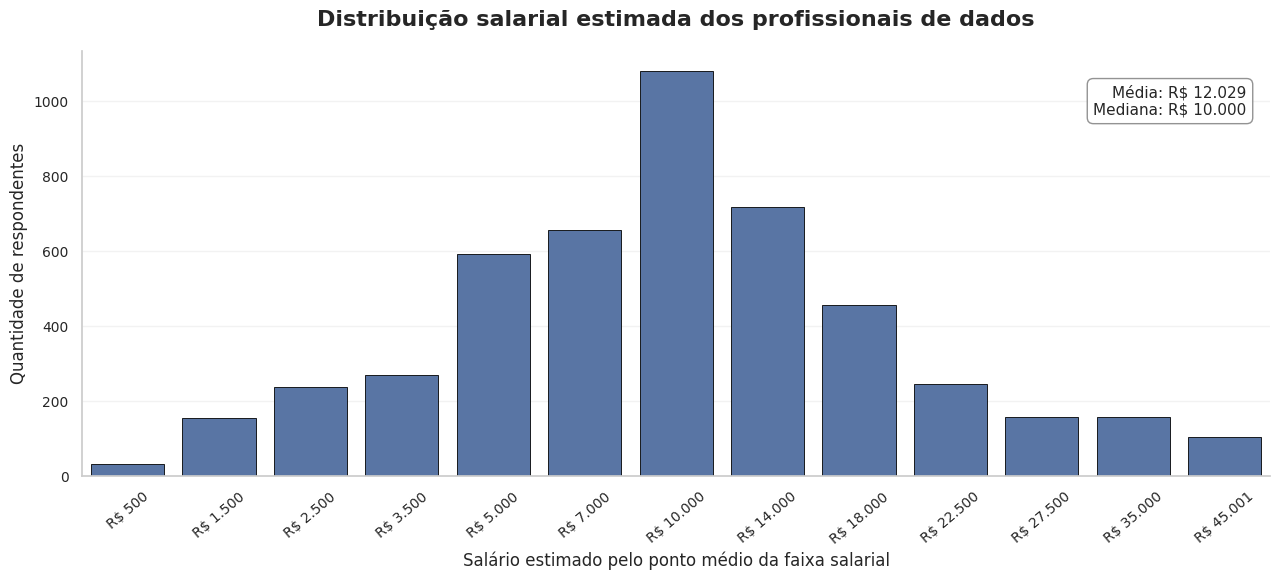

In [24]:
plotar_histograma(df_salarios, "salario_medio")

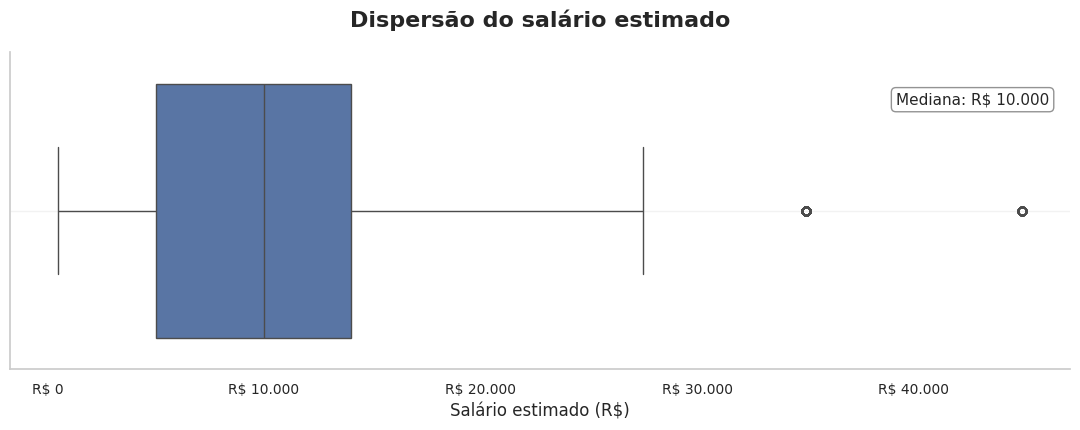

In [25]:
plotar_boxplot(df_salarios, "salario_medio")

### 3.5.2 Distribuição da idade

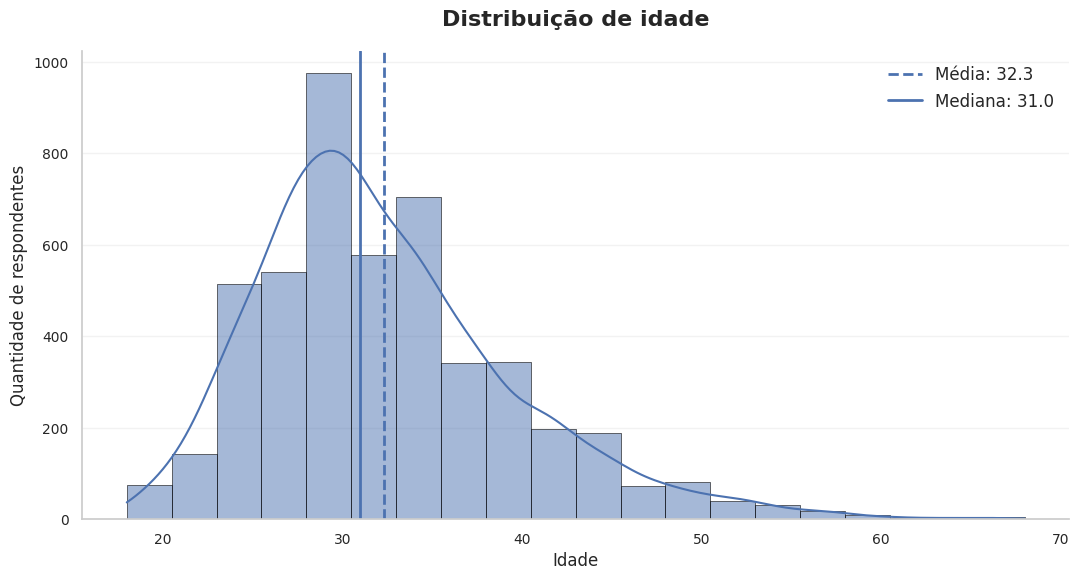

In [26]:
plotar_histograma(df_salarios, "idade")

### 3.5.3 Distribuição da senioridade

A senioridade foi transformada em uma variável ordinal para permitir análise estatística. A escala utilizada foi: Júnior = 1, Pleno = 2 e Sênior = 3.

Essa escala representa apenas uma ordem crescente de senioridade. Ela não significa que a distância entre Júnior e Pleno seja exatamente igual à distância entre Pleno e Sênior.

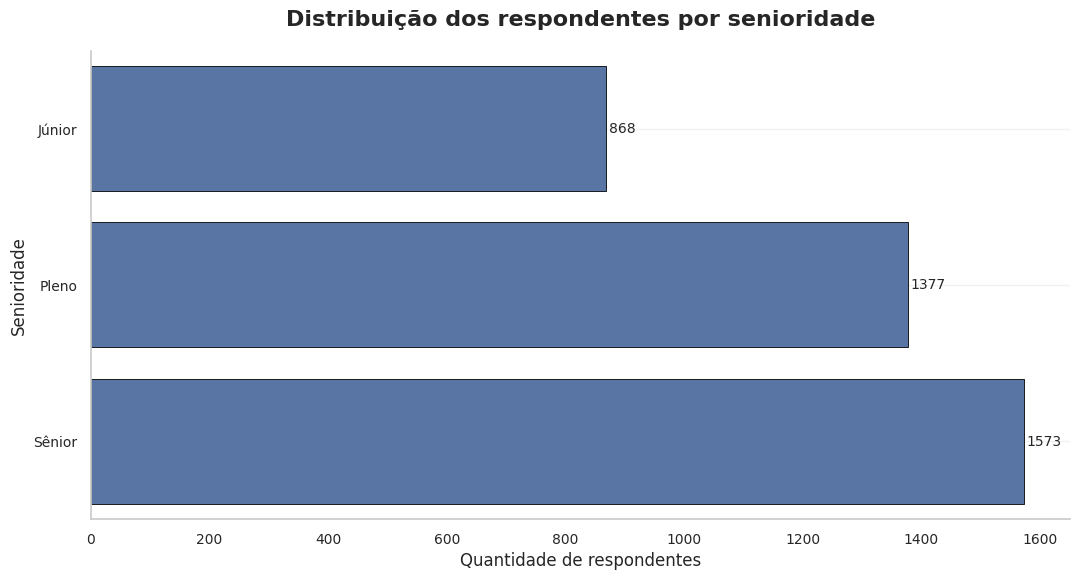

In [27]:
plotar_barras(df_salarios, "senioridade_ordem")

### 3.5.4 Distribuição da experiência em dados

A variável de experiência em dados foi transformada em uma escala ordinal aproximada para representar a progressão do tempo de atuação na área. Como se trata de uma variável ordinal, os gráficos ajudam a entender a concentração dos respondentes em diferentes níveis de experiência, mas não devem ser interpretados como uma medida contínua exata.

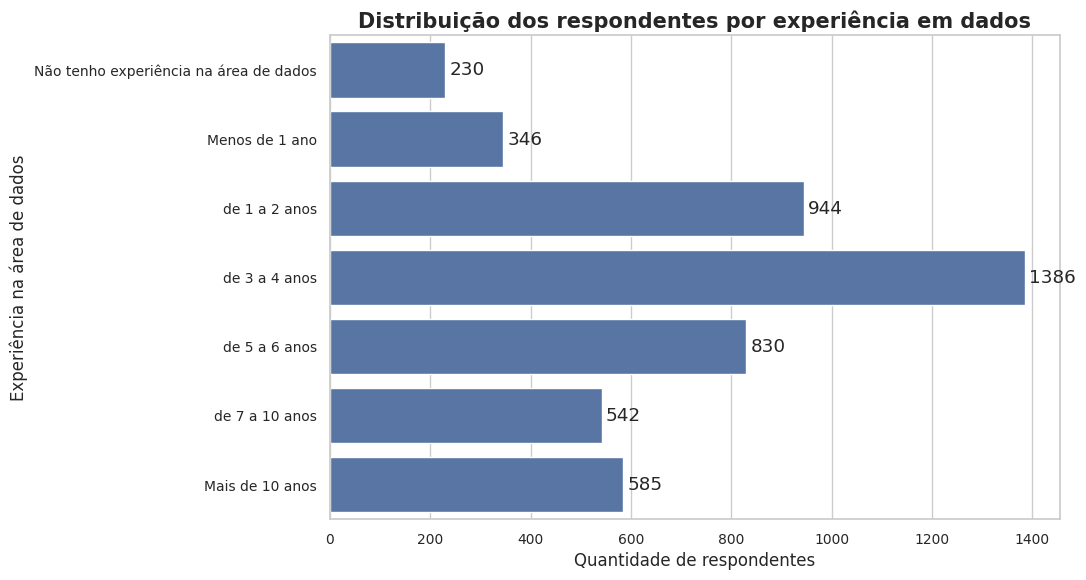

In [28]:
ordem_experiencia = (
    df_salarios[["experiencia_dados", "experiencia_dados_ordem"]]
    .drop_duplicates()
    .dropna()
    .sort_values("experiencia_dados_ordem")["experiencia_dados"]
)

plt.figure(figsize=(11, 6))

ax = sns.countplot(
    data=df_salarios,
    y="experiencia_dados",
    order=ordem_experiencia
)

plt.title("Distribuição dos respondentes por experiência em dados", fontsize=15, weight="bold")
plt.xlabel("Quantidade de respondentes")
plt.ylabel("Experiência na área de dados")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### 3.5.5 Distribuição das variáveis categóricas

Além das variáveis numéricas e ordinais analisadas anteriormente, também observamos a frequência de variáveis categóricas importantes para caracterizar a amostra, como cargo, região, gênero, raça/cor e nível de ensino.

Senioridade e experiência já foram visualizadas nas seções anteriores, por isso não serão repetidas nos gráficos desta seção. Elas permanecem nas tabelas de frequência para conferência, mas os gráficos categóricos serão concentrados nas variáveis ainda não exploradas visualmente.

Nos gráficos categóricos, foram exibidas até as 10 categorias mais frequentes de cada variável para manter a visualização legível. As tabelas de frequência preservam a distribuição completa.

In [29]:
variaveis_categoricas_tabela = [
    "cargo_padronizado",
    "senioridade_padronizada",
    "experiencia_dados",
    "regiao",
    "genero_grafico",
    "cor_raca_etnia_grafico",
    "nivel_ensino"
]

variaveis_categoricas_tabela = [
    coluna for coluna in variaveis_categoricas_tabela
    if coluna in df_salarios.columns
]

variaveis_categoricas_grafico = [
    "cargo_padronizado",
    "regiao",
    "nivel_ensino"
]

variaveis_categoricas_grafico = [
    coluna for coluna in variaveis_categoricas_grafico
    if coluna in df_salarios.columns
]

In [30]:
for coluna in variaveis_categoricas_tabela:
    tabela_freq = (
        df_salarios[coluna]
        .value_counts(dropna=False)
        .to_frame("frequencia")
    )

    tabela_freq["percentual"] = (
        tabela_freq["frequencia"] / tabela_freq["frequencia"].sum() * 100
    ).round(2)

    print(f"\nDistribuição de {coluna}")
    display(tabela_freq.head(10))


Distribuição de cargo_padronizado


,frequencia,percentual
cargo_padronizado,,
Não informado,1045,21.49
Analista de Dados,957,19.68
Cientista de Dados,687,14.13
Engenheiro de Dados,613,12.61
Outros,584,12.01
Analista de BI,396,8.14
Analytics Engineer,228,4.69
Outras funções técnicas,170,3.50
Engenheiro de Machine Learning,103,2.12



Distribuição de senioridade_padronizada


,frequencia,percentual
senioridade_padronizada,,
Sênior,1573,32.35
Pleno,1377,28.32
Não informado,1045,21.49
Júnior,868,17.85



Distribuição de experiencia_dados


...

,frequencia,percentual
genero_grafico,,
Masculino,3700,76.08
Feminino,1142,23.48
Prefiro não informar,15,0.31
Outro,6,0.12



Distribuição de cor_raca_etnia_grafico


,frequencia,percentual
cor_raca_etnia_grafico,,
Branca,3284,67.53
Parda,1067,21.94
Preta,309,6.35
Amarela,152,3.13
Prefiro não informar,36,0.74
Indígena,10,0.21
Outra,5,0.10



Distribuição de nivel_ensino


,frequencia,percentual
nivel_ensino,,
Pós-graduação,1860,38.25
Graduação/Bacharelado,1618,33.27
Mestrado,620,12.75
Estudante de Graduação,492,10.12
Doutorado ou Phd,192,3.95
Não tenho graduação formal,77,1.58
Prefiro não informar,4,0.08


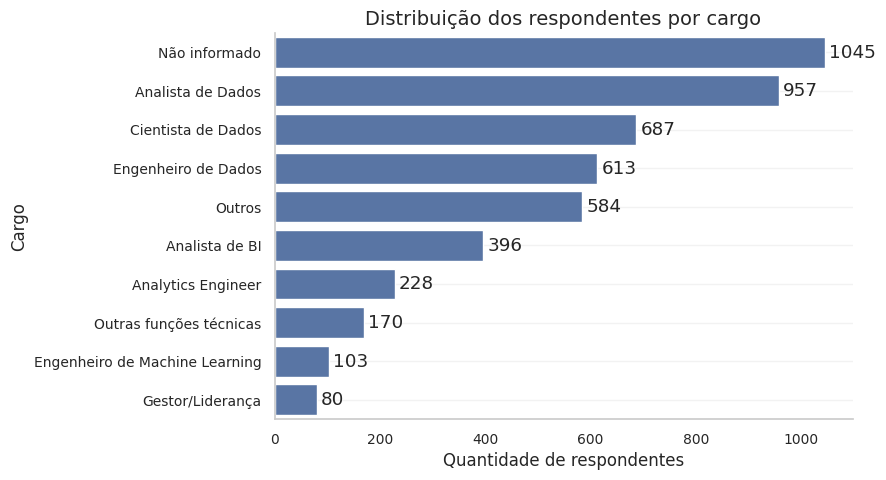

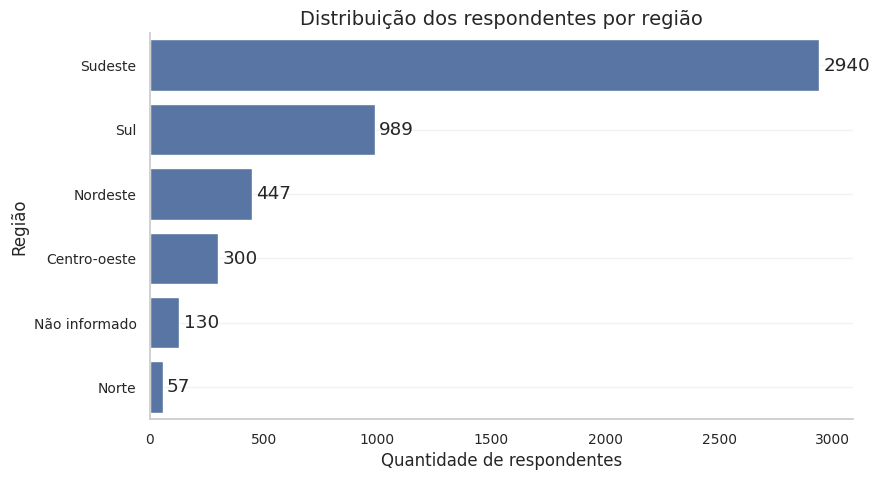

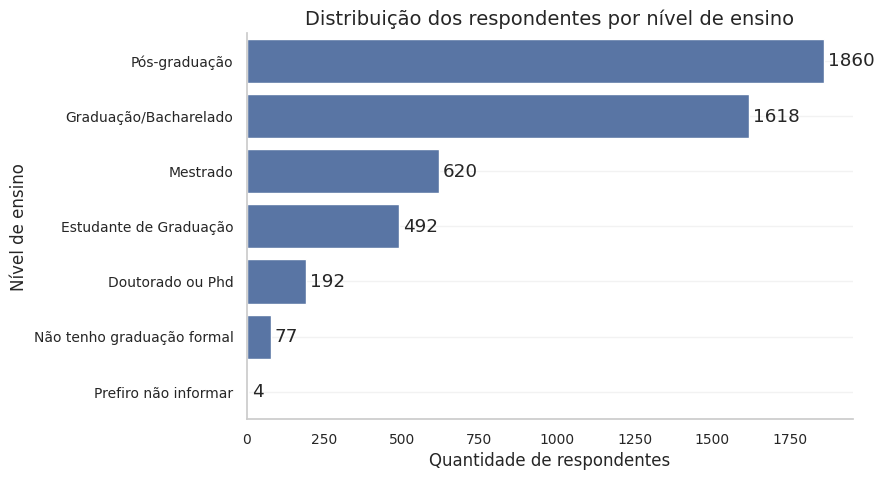

In [31]:
titulos_categoricas = {
    "cargo_padronizado": "Distribuição dos respondentes por cargo",
    "regiao": "Distribuição dos respondentes por região",
    "genero_grafico": "Distribuição dos respondentes por gênero",
    "cor_raca_etnia_grafico": "Distribuição dos respondentes por raça/cor/etnia",
    "nivel_ensino": "Distribuição dos respondentes por nível de ensino"
}

rotulos_y = {
    "cargo_padronizado": "Cargo",
    "regiao": "Região",
    "genero_grafico": "Gênero",
    "cor_raca_etnia_grafico": "Raça/cor/etnia",
    "nivel_ensino": "Nível de ensino"
}

for coluna in variaveis_categoricas_grafico:
    plt.figure(figsize=(9, 5))

    ordem = df_salarios[coluna].value_counts().head(10).index

    ax = sns.countplot(
        data=df_salarios,
        y=coluna,
        order=ordem
    )

    plt.title(titulos_categoricas.get(coluna, f"Distribuição de {coluna}"), fontsize=14)
    plt.xlabel("Quantidade de respondentes")
    plt.ylabel(rotulos_y.get(coluna, coluna))

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    limpar_visual(ax)

    plt.tight_layout()
    plt.show()

## Etapa 4 - Análise bivariada

**Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?**

<br>

Para responder a essa pergunta, vamos cruzar o salário com variáveis profissionais e demográficas, como senioridade, experiência na área de dados, cargo, região e gênero.

Essa associação não significa causalidade. Se determinado grupo apresenta salário mediano maior, isso não prova que a variável analisada causa esse salário maior. Pode haver influência de senioridade, cargo, região, setor ou tempo de experiência.

<br>

Nesta etapa, continuaremos usando `df_salarios`, que é uma base derivada do `df_subset` e contém apenas registros com salário válido.

### 4.1 Funções auxiliares para análise bivariada

In [32]:
def resumo_salario_por_grupo(df, grupo, salario="salario_medio", min_observacoes=20):

    # Gera uma tabela-resumo do salário por grupo.
    # Para evitar conclusões frágeis, grupos com poucas observações
    # podem ser filtrados usando o parâmetro min_observacoes.

    tabela = (
        df.groupby(grupo)[salario]
          .agg(
              qtd_respondentes="count",
              media="mean",
              mediana="median",
              desvio_padrao="std",
              minimo="min",
              maximo="max"
          )
          .reset_index()
    )

    tabela = tabela[tabela["qtd_respondentes"] >= min_observacoes]

    tabela["media"] = tabela["media"].round(2)
    tabela["mediana"] = tabela["mediana"].round(2)
    tabela["desvio_padrao"] = tabela["desvio_padrao"].round(2)

    return tabela.sort_values("mediana", ascending=False)


def plotar_salario_mediano_por_grupo(df, grupo, titulo, xlabel, ylabel, min_observacoes=20):
    """
    Plota salário mediano por grupo.
    """
    tabela = resumo_salario_por_grupo(
        df=df,
        grupo=grupo,
        salario="salario_medio",
        min_observacoes=min_observacoes
    )

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=tabela,
        x="mediana",
        y=grupo
    )

    plt.title(titulo, fontsize=15, weight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    ax.xaxis.set_major_formatter(FuncFormatter(formatar_reais))

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[formatar_reais(v) for v in container.datavalues],
            padding=3,
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    return tabela

### 4.2 Salário x Senioridade

A senioridade é uma das variáveis mais importantes para explicar diferenças salariais, pois representa o nível de maturidade profissional, responsabilidade e experiência esperada do respondente.

Analisamos se o salário mediano estimado aumenta conforme o nível de senioridade. Como a senioridade foi transformada em uma variável ordinal (`senioridade_ordem`), também calculamos a correlação de Spearman, que é mais adequada quando uma das variáveis possui ordem, mas não é originalmente numérica contínua.

In [33]:
df_senioridade_grafico = df_salarios[
    df_salarios["senioridade_padronizada"] != "Não informado"
].copy()

tabela_salario_senioridade = resumo_salario_por_grupo(
    df=df_senioridade_grafico,
    grupo="senioridade_padronizada",
    min_observacoes=20
)

tabela_salario_senioridade

,senioridade_padronizada,qtd_respondentes,media,mediana,desvio_padrao,minimo,maximo
2,Sênior,1573,14604.45,14000.5,7569.68,500.0,45001.0
1,Pleno,1377,8047.70,7000.5,4172.90,500.0,35000.5
0,Júnior,868,4157.74,3500.5,3233.50,500.0,45001.0


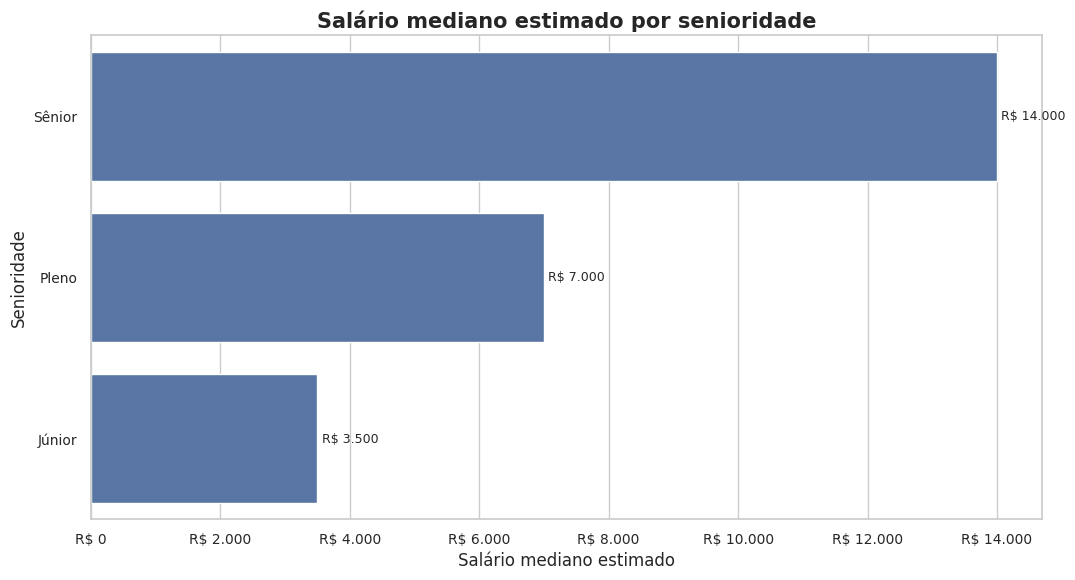

In [34]:
_ = plotar_salario_mediano_por_grupo(
    df=df_senioridade_grafico,
    grupo="senioridade_padronizada",
    titulo="Salário mediano estimado por senioridade",
    xlabel="Salário mediano estimado",
    ylabel="Senioridade",
    min_observacoes=20
)

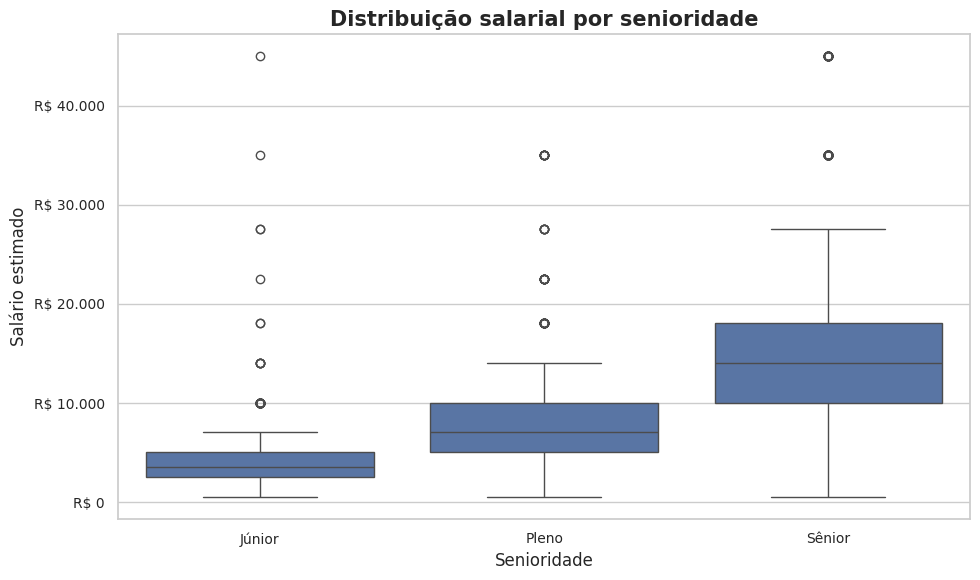

In [35]:
plt.figure(figsize=(10, 6))

ordem_senioridade = ["Júnior", "Pleno", "Sênior"]

ax = sns.boxplot(
    data=df_senioridade_grafico,
    x="senioridade_padronizada",
    y="salario_medio",
    order=ordem_senioridade
)

plt.title("Distribuição salarial por senioridade", fontsize=15, weight="bold")
plt.xlabel("Senioridade")
plt.ylabel("Salário estimado")

ax.yaxis.set_major_formatter(FuncFormatter(formatar_reais))

plt.tight_layout()
plt.show()

In [36]:
# Correlação entre senioridade ordinal e salário
dados_correlacao_senioridade = df_salarios[
    ["senioridade_ordem", "salario_medio"]
].dropna()

correlacao_spearman_senioridade = dados_correlacao_senioridade[
    "senioridade_ordem"
].corr(
    dados_correlacao_senioridade["salario_medio"],
    method="spearman"
)

correlacao_pearson_senioridade = dados_correlacao_senioridade[
    "senioridade_ordem"
].corr(
    dados_correlacao_senioridade["salario_medio"],
    method="pearson"
)

print(f"Correlação de Spearman entre senioridade e salário: {correlacao_spearman_senioridade:.3f}")
print(f"Correlação de Pearson entre senioridade e salário: {correlacao_pearson_senioridade:.3f}")

Correlação de Spearman entre senioridade e salário: 0.734
Correlação de Pearson entre senioridade e salário: 0.590


A análise indica que existe uma relação positiva entre senioridade e salário. Em geral, os níveis mais altos de senioridade apresentam salários medianos maiores do que os níveis iniciais.

A correlação de Spearman entre senioridade e salário foi positiva, indicando que, conforme a senioridade aumenta, o salário tende a aumentar também. Esse resultado é esperado, pois profissionais mais seniores geralmente acumulam mais experiência, assumem maior responsabilidade técnica ou estratégica e tendem a ocupar posições com maior remuneração.

### 4.3 Salário × experiência na área de dados

Além da senioridade, o tempo de experiência na área de dados é um fator importante para entender diferenças salariais. Enquanto a senioridade indica o nível atual do cargo, a experiência em dados representa o tempo acumulado de atuação na área.

Nesta análise, comparamos o salário mediano estimado entre os grupos de experiência. Também calculamos a correlação de Spearman, pois a experiência foi transformada em uma variável ordinal, representando uma progressão aproximada de tempo.

A categoria "Não informado" será mantida na base, mas removida da tabela e do gráfico comparativo principal, pois não representa um nível real de experiência.

In [37]:
df_experiencia_grafico = df_salarios[
    df_salarios["experiencia_dados"] != "Não informado"
].copy()

tabela_salario_experiencia = resumo_salario_por_grupo(
    df=df_experiencia_grafico,
    grupo="experiencia_dados",
    min_observacoes=20
)

tabela_salario_experiencia

,experiencia_dados,qtd_respondentes,media,mediana,desvio_padrao,minimo,maximo
0,Mais de 10 anos,585,20939.00,18000.5,10507.71,500.0,45001.0
5,de 5 a 6 anos,830,15233.04,14000.5,7952.97,500.0,45001.0
6,de 7 a 10 anos,542,18026.35,14000.5,9764.77,2500.5,45001.0
4,de 3 a 4 anos,1386,10316.16,10000.5,6158.00,1500.5,45001.0
2,Não tenho experiência na área de dados,230,6541.78,5000.5,6730.45,500.0,45001.0
3,de 1 a 2 anos,944,6658.34,5000.5,4984.30,500.0,45001.0
1,Menos de 1 ano,346,5040.95,3500.5,5155.99,500.0,45001.0


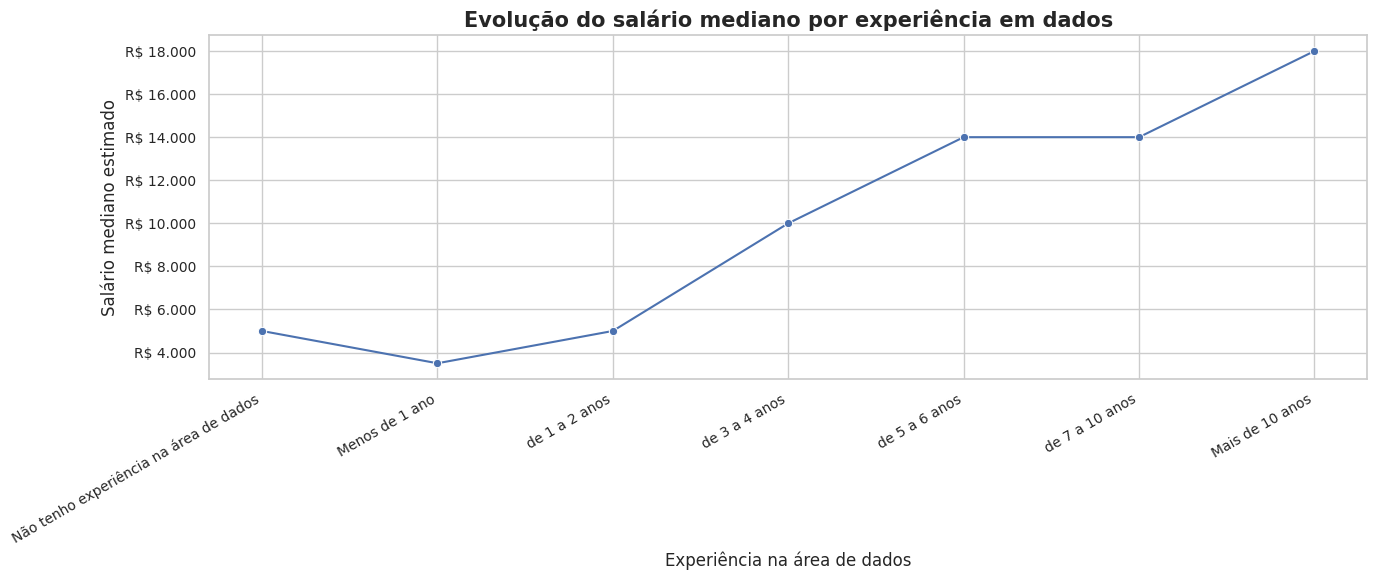

In [38]:
tabela_experiencia_linha = (
    tabela_salario_experiencia
    .merge(
        df_experiencia_grafico[["experiencia_dados", "experiencia_dados_ordem"]]
        .drop_duplicates(),
        on="experiencia_dados",
        how="left"
    )
    .sort_values("experiencia_dados_ordem")
)

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=tabela_experiencia_linha,
    x="experiencia_dados",
    y="mediana",
    marker="o"
)

plt.title("Evolução do salário mediano por experiência em dados", fontsize=15, weight="bold")
plt.xlabel("Experiência na área de dados")
plt.ylabel("Salário mediano estimado")

ax.yaxis.set_major_formatter(FuncFormatter(formatar_reais))
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [39]:
dados_correlacao_experiencia = df_salarios[
    ["experiencia_dados_ordem", "salario_medio"]
].dropna()

correlacao_spearman_experiencia = dados_correlacao_experiencia[
    "experiencia_dados_ordem"
].corr(
    dados_correlacao_experiencia["salario_medio"],
    method="spearman"
)

correlacao_pearson_experiencia = dados_correlacao_experiencia[
    "experiencia_dados_ordem"
].corr(
    dados_correlacao_experiencia["salario_medio"],
    method="pearson"
)

print(f"Correlação de Spearman entre experiência em dados e salário: {correlacao_spearman_experiencia:.3f}")
print(f"Correlação de Pearson entre experiência em dados e salário: {correlacao_pearson_experiencia:.3f}")

Correlação de Spearman entre experiência em dados e salário: 0.658
Correlação de Pearson entre experiência em dados e salário: 0.564


A análise indica que o salário mediano estimado tende a aumentar conforme cresce o tempo de experiência na área de dados. Esse resultado reforça a ideia de que trajetória acumulada na área é um fator relevante para a remuneração.

A correlação de Spearman entre experiência em dados e salário foi positiva, indicando que profissionais com mais tempo de atuação tendem a estar associados a salários maiores. No entanto, essa relação deve ser interpretada como associação, não como causalidade direta, pois experiência também se relaciona com senioridade, cargo, tipo de empresa e responsabilidades assumidas.

### 4.4 Salário × cargo

In [40]:
df_cargo_grafico = df_salarios[
    ~df_salarios["cargo_padronizado"].isin(["Não informado", "Outros"])
].copy()

tabela_salario_cargo = resumo_salario_por_grupo(
    df=df_cargo_grafico,
    grupo="cargo_padronizado",
    min_observacoes=20
)

tabela_salario_cargo

,cargo_padronizado,qtd_respondentes,media,mediana,desvio_padrao,minimo,maximo
5,Engenheiro de Machine Learning,103,15840.33,14000.5,10228.64,1500.5,45001.0
3,Cientista de Dados,687,11865.86,10000.5,6716.84,500.0,45001.0
4,Engenheiro de Dados,613,12876.53,10000.5,8835.01,500.0,45001.0
2,Analytics Engineer,228,10873.31,10000.5,6087.76,1500.5,35000.5
6,Gestor/Liderança,80,11931.75,10000.5,5119.92,1500.5,35000.5
7,Outras funções técnicas,170,11138.73,10000.5,7960.54,500.0,45001.0
1,Analista de Dados,957,8007.81,7000.5,5227.77,500.0,45001.0
0,Analista de BI,396,6511.85,5000.5,3785.96,500.0,22500.5


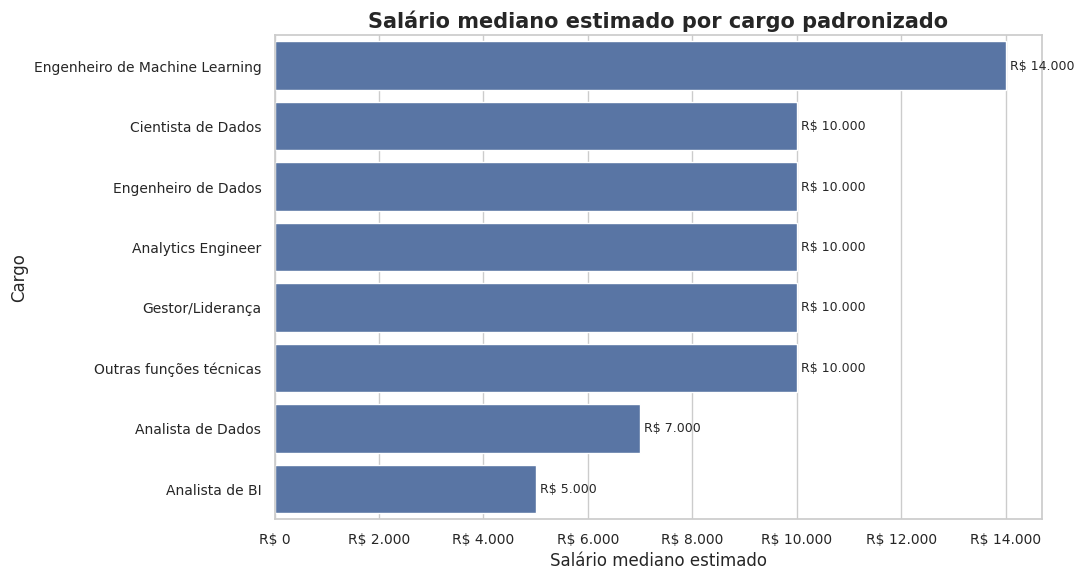

In [41]:
_ = plotar_salario_mediano_por_grupo(
    df=df_cargo_grafico,
    grupo="cargo_padronizado",
    titulo="Salário mediano estimado por cargo padronizado",
    xlabel="Salário mediano estimado",
    ylabel="Cargo",
    min_observacoes=20
)

A comparação por cargo mostra diferenças relevantes de remuneração entre funções. Cargos ligados a liderança, engenharia, ciência de dados ou funções mais especializadas tendem a apresentar salários medianos superiores aos cargos mais operacionais ou iniciais.

Essa diferença deve ser interpretada junto com a senioridade. Um cargo pode parecer mais bem remunerado não apenas pela função em si, mas também porque concentra mais profissionais seniores ou gestores.

A categoria "Outros" também foi removida do gráfico principal por reunir cargos muito diferentes entre si, o que dificulta uma interpretação salarial clara. Ela permanece na base tratada, mas não foi usada como categoria explicativa principal.

### 4.5 Salário × região

A região onde o profissional mora pode influenciar o salário por diferenças econômicas, concentração de empresas, custo de vida e oportunidades no mercado de tecnologia.

Neste cruzamento, comparamos o salário mediano estimado entre as regiões brasileiras. A mediana é usada como medida principal porque a distribuição salarial é assimétrica, ou seja, alguns salários muito altos podem puxar a média para cima.

In [42]:
df_regiao_grafico = df_salarios[
    df_salarios["regiao"] != "Não informado"
].copy()

tabela_salario_regiao = resumo_salario_por_grupo(
    df=df_regiao_grafico,
    grupo="regiao",
    min_observacoes=20
)

tabela_salario_regiao

,regiao,qtd_respondentes,media,mediana,desvio_padrao,minimo,maximo
4,Sul,989,10447.42,10000.5,7517.39,500.0,45001.0
3,Sudeste,2940,12711.90,10000.5,9124.86,500.0,45001.0
0,Centro-oeste,300,10165.49,7000.5,7899.27,500.0,35000.5
2,Norte,57,8711.02,7000.5,6803.99,500.0,35000.5
1,Nordeste,447,9743.23,7000.5,8226.11,500.0,45001.0


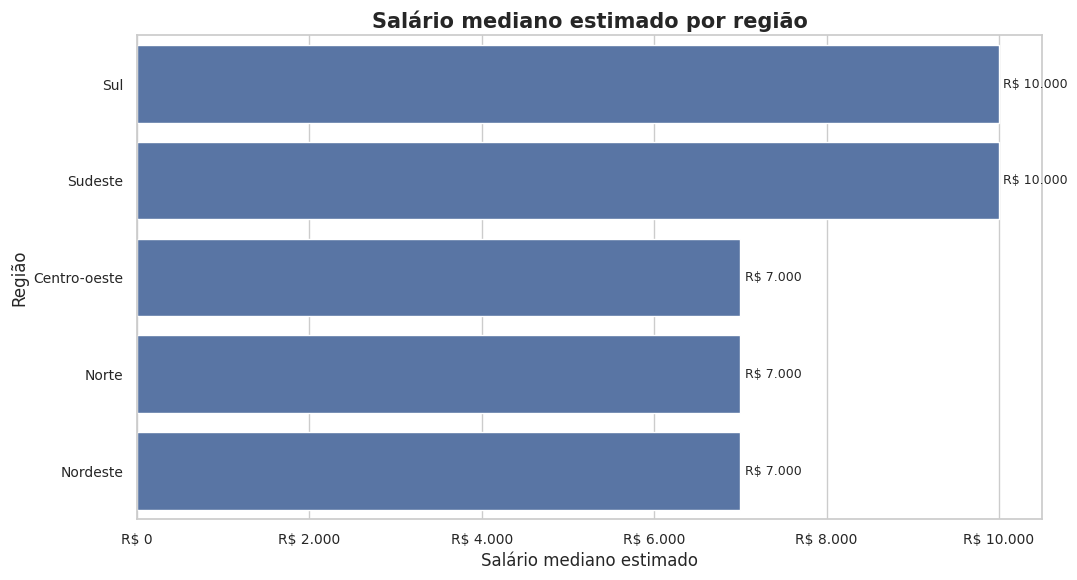

In [43]:
_ = plotar_salario_mediano_por_grupo(
    df=df_regiao_grafico,
    grupo="regiao",
    titulo="Salário mediano estimado por região",
    xlabel="Salário mediano estimado",
    ylabel="Região",
    min_observacoes=20
)

A análise por região permite observar se há concentração de salários mais altos em determinadas partes do país. Diferenças regionais podem estar relacionadas à concentração de empresas de tecnologia, presença de grandes centros econômicos, oportunidades remotas e custo de vida.

No entanto, a região isoladamente não deve ser interpretada como causa direta do salário. É possível que algumas regiões concentrem mais profissionais seniores, gestores ou pessoas trabalhando em empresas maiores.

A categoria "Não informado" foi mantida na base e nas verificações de qualidade, mas removida das tabelas e gráficos comparativos principais. Essa decisão evita interpretar ausência de resposta como se fosse um fator real associado ao salário.

### 4.6 Salário × gênero

A análise de salário por gênero exige cuidado ético. Diferenças salariais observadas entre grupos não devem ser interpretadas automaticamente como discriminação direta, pois podem estar associadas a outras variáveis, como senioridade, cargo, setor, região e tempo de experiência.

Por isso, primeiro observamos a diferença salarial geral por gênero e, em seguida, fazemos uma comparação controlada por senioridade. Esse controle simples ajuda a verificar se as diferenças permanecem quando comparamos profissionais dentro do mesmo nível profissional.

In [44]:
tabela_salario_genero_completa = resumo_salario_por_grupo(
    df=df_salarios,
    grupo="genero_grafico",
    min_observacoes=1
)

tabela_salario_genero_completa

,genero_grafico,qtd_respondentes,media,mediana,desvio_padrao,minimo,maximo
0,Feminino,1142,10163.37,10000.5,7227.10,500.0,45001.0
1,Masculino,3700,12586.72,10000.5,9358.42,500.0,45001.0
3,Prefiro não informar,15,15467.27,10000.5,15896.59,1500.5,45001.0
2,Outro,6,14333.92,8500.5,15095.46,7000.5,45001.0


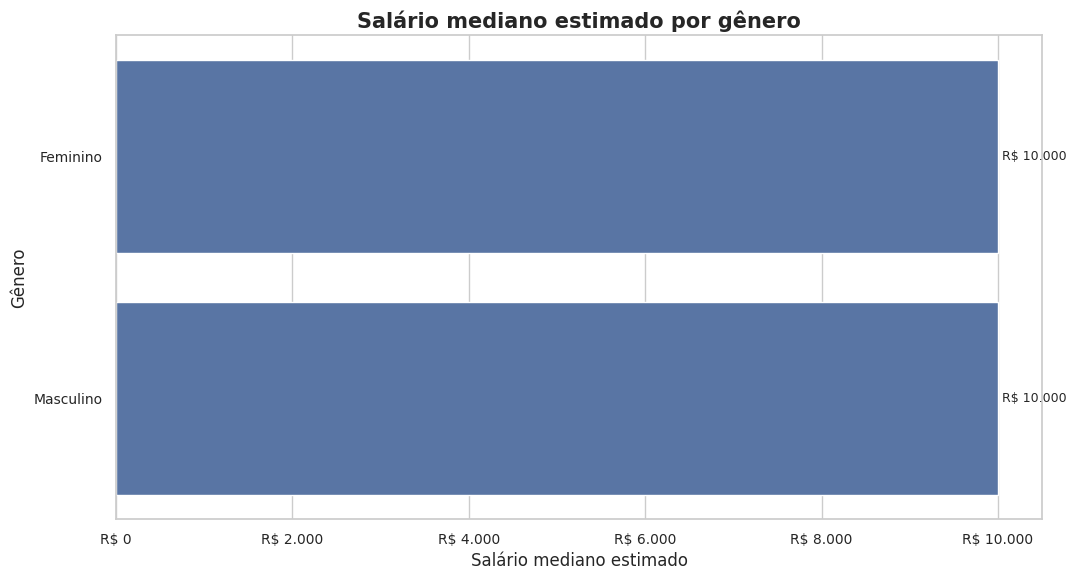

In [45]:
_ = plotar_salario_mediano_por_grupo(
    df=df_salarios,
    grupo="genero_grafico",
    titulo="Salário mediano estimado por gênero",
    xlabel="Salário mediano estimado",
    ylabel="Gênero",
    min_observacoes=20
)

In [46]:
# Tabela de salário mediano por gênero dentro de cada senioridade
# Removemos "Não informado" da senioridade porque não representa um nível profissional real.

tabela_genero_senioridade = (
    df_salarios
    .query("senioridade_padronizada != 'Não informado'")
    .groupby(["senioridade_padronizada", "genero_grafico"])["salario_medio"]
    .agg(
        qtd_respondentes="count",
        mediana="median",
        media="mean"
    )
    .reset_index()
)

# Filtrar grupos muito pequenos para evitar interpretações frágeis
tabela_genero_senioridade = tabela_genero_senioridade[
    tabela_genero_senioridade["qtd_respondentes"] >= 20
]

tabela_genero_senioridade["mediana"] = tabela_genero_senioridade["mediana"].round(2)
tabela_genero_senioridade["media"] = tabela_genero_senioridade["media"].round(2)

tabela_genero_senioridade.sort_values(
    ["senioridade_padronizada", "mediana"],
    ascending=[True, False]
)

,senioridade_padronizada,genero_grafico,qtd_respondentes,mediana,media
0,Júnior,Feminino,242,3500.5,4149.25
1,Júnior,Masculino,623,3500.5,4102.41
3,Pleno,Feminino,366,7000.5,7817.44
4,Pleno,Masculino,1006,7000.5,8133.70
8,Sênior,Masculino,1229,14000.5,15172.60
7,Sênior,Feminino,335,10000.5,12543.79


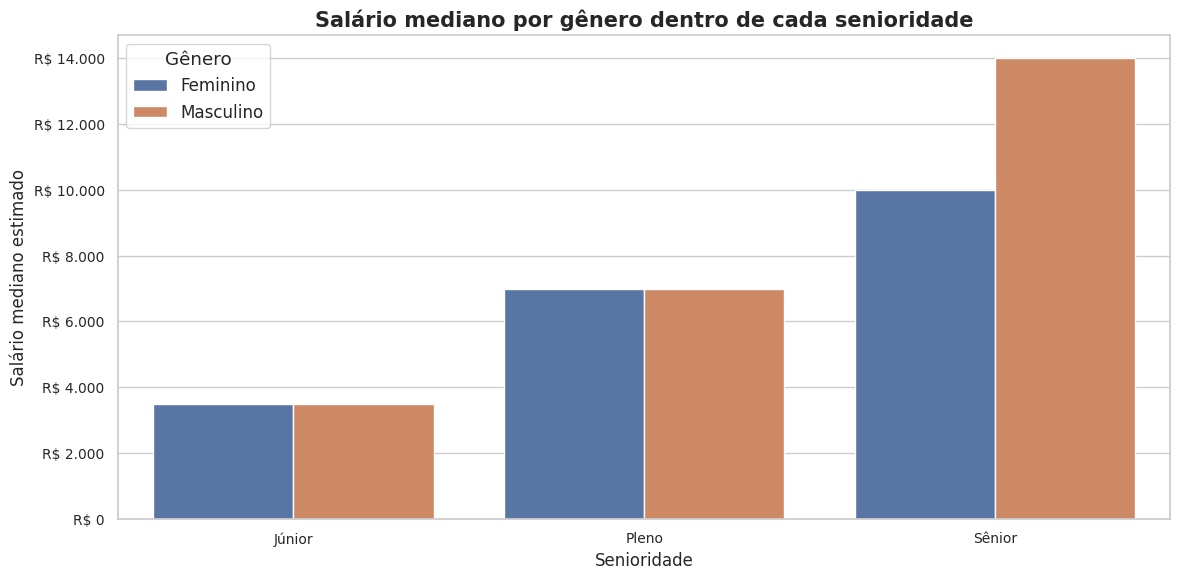

In [47]:
ordem_senioridade = ["Júnior", "Pleno", "Sênior"]

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=tabela_genero_senioridade,
    x="senioridade_padronizada",
    y="mediana",
    hue="genero_grafico",
    order=ordem_senioridade
)

plt.title("Salário mediano por gênero dentro de cada senioridade", fontsize=15, weight="bold")
plt.xlabel("Senioridade")
plt.ylabel("Salário mediano estimado")

ax.yaxis.set_major_formatter(FuncFormatter(formatar_reais))

plt.legend(title="Gênero")
plt.tight_layout()
plt.show()

A comparação geral por gênero mostra diferenças salariais entre grupos, mas essa leitura isolada pode ser incompleta. Por isso, a análise foi complementada com uma comparação dentro de cada nível de senioridade.

Esse cuidado é importante porque a composição dos grupos pode ser diferente. Se um grupo tiver maior concentração de profissionais seniores ou gestores, seu salário mediano tende a ser maior independentemente do gênero.

Assim, os resultados de gênero devem ser comunicados com cautela, destacando que a pesquisa permite observar diferenças salariais declaradas, mas não permite afirmar causalidade nem discriminação direta sem modelos mais controlados e informações adicionais.

## Etapa 5 — Gráfico-síntese

Nesta etapa, construímos um gráfico-síntese para responder diretamente à pergunta central do trabalho:

<br>

**Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?**

<br>

A análise bivariada mostrou que senioridade e experiência na área de dados foram os fatores com associação mais clara com o salário. Por isso, o gráfico-síntese cruza essas duas variáveis e mostra o salário mediano estimado em cada combinação.

A mediana foi usada porque o salário original está em faixas e foi convertido para ponto médio. Assim, a mediana representa melhor o salário típico de cada grupo e reduz o efeito de valores extremos.

In [48]:
# Base para o gráfico-síntese
# Usamos apenas registros com senioridade e experiência válidas,
# pois o objetivo é comparar níveis reais de maturidade profissional.

df_heatmap = df_salarios[
    df_salarios["senioridade_ordem"].notna() &
    df_salarios["experiencia_dados_ordem"].notna()
].copy()

# Ordem natural da senioridade
ordem_senioridade = ["Júnior", "Pleno", "Sênior"]

# Ordem natural da experiência em dados
ordem_experiencia = (
    df_heatmap[["experiencia_dados", "experiencia_dados_ordem"]]
    .drop_duplicates()
    .sort_values("experiencia_dados_ordem")["experiencia_dados"]
    .tolist()
)

# Tabela-base do heatmap
tabela_heatmap = (
    df_heatmap
    .groupby(["experiencia_dados", "senioridade_padronizada"])
    .agg(
        qtd_respondentes=("salario_medio", "count"),
        mediana_salario=("salario_medio", "median")
    )
    .reset_index()
)

# Filtrar combinações com poucos respondentes
# Isso evita exibir medianas instáveis.
min_observacoes_heatmap = 20

tabela_heatmap_filtrada = tabela_heatmap[
    tabela_heatmap["qtd_respondentes"] >= min_observacoes_heatmap
].copy()

tabela_heatmap_filtrada

,experiencia_dados,senioridade_padronizada,qtd_respondentes,mediana_salario
1,Mais de 10 anos,Pleno,23,10000.5
2,Mais de 10 anos,Sênior,245,14000.5
3,Menos de 1 ano,Júnior,240,2500.5
4,Menos de 1 ano,Pleno,52,5000.5
5,Menos de 1 ano,Sênior,26,12000.5
6,Não tenho experiência na área de dados,Júnior,108,2500.5
7,Não tenho experiência na área de dados,Pleno,47,5000.5
8,Não tenho experiência na área de dados,Sênior,33,10000.5
9,de 1 a 2 anos,Júnior,391,3500.5
10,de 1 a 2 anos,Pleno,380,7000.5


In [49]:
# Matriz com as medianas salariais
matriz_salario = tabela_heatmap_filtrada.pivot_table(
    index="experiencia_dados",
    columns="senioridade_padronizada",
    values="mediana_salario",
    aggfunc="median"
)

# Matriz com a quantidade de respondentes
matriz_qtd = tabela_heatmap_filtrada.pivot_table(
    index="experiencia_dados",
    columns="senioridade_padronizada",
    values="qtd_respondentes",
    aggfunc="sum"
)

# Aplicar ordenação natural
matriz_salario = matriz_salario.reindex(
    index=ordem_experiencia,
    columns=ordem_senioridade
)

matriz_qtd = matriz_qtd.reindex(
    index=ordem_experiencia,
    columns=ordem_senioridade
)

matriz_salario

senioridade_padronizada,Júnior,Pleno,Sênior
experiencia_dados,,,
Não tenho experiência na área de dados,2500.5,5000.5,10000.5
Menos de 1 ano,2500.5,5000.5,12000.5
de 1 a 2 anos,3500.5,7000.5,10000.5
de 3 a 4 anos,5000.5,7000.5,10000.5
de 5 a 6 anos,NaN,10000.5,14000.5
de 7 a 10 anos,NaN,10000.5,14000.5
Mais de 10 anos,NaN,10000.5,14000.5


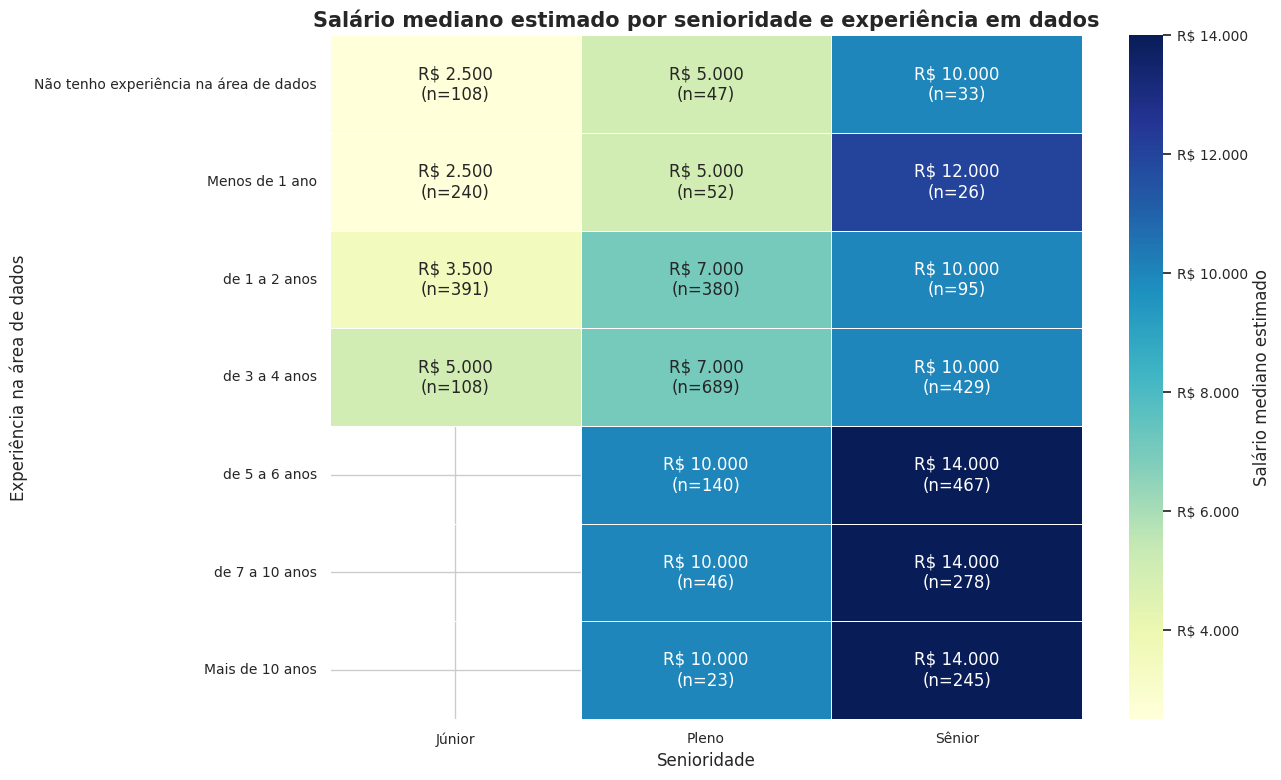

In [50]:
# Criar anotações com salário formatado e quantidade de respondentes
anotacoes = matriz_salario.copy().astype(object)

for linha in matriz_salario.index:
    for coluna in matriz_salario.columns:
        valor = matriz_salario.loc[linha, coluna]
        qtd = matriz_qtd.loc[linha, coluna]

        if pd.notna(valor):
            anotacoes.loc[linha, coluna] = f"{formatar_reais(valor)}\n(n={int(qtd)})"
        else:
            anotacoes.loc[linha, coluna] = ""

plt.figure(figsize=(13, 8))

ax = sns.heatmap(
    matriz_salario,
    annot=anotacoes,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.6,
    linecolor="white",
    mask=matriz_salario.isna(),
    annot_kws={"fontsize": 12},
    cbar_kws={"label": "Salário mediano estimado"}
)

plt.title(
    "Salário mediano estimado por senioridade e experiência em dados",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Senioridade")
plt.ylabel("Experiência na área de dados")

# Formatar legenda de cor em reais
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(FuncFormatter(formatar_reais))

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 5.1 Interpretação do gráfico-síntese

O heatmap mostra o salário mediano estimado a partir da combinação entre senioridade e experiência na área de dados. As células apresentam o salário mediano e a quantidade de respondentes usada no cálculo, indicada por `n`.

Observa-se que os salários medianos tendem a aumentar conforme avançam a senioridade e o tempo de experiência. As menores medianas aparecem entre profissionais Júnior e com menor tempo de atuação, enquanto as maiores medianas se concentram entre profissionais Sênior e com mais experiência.

As células em branco representam combinações com menos de 20 respondentes ou sem dados suficientes. De forma geral, o gráfico reforça que o salário está associado à maturidade profissional, ao tempo de experiência e ao tipo de função exercida.

## Conclusão geral do notebook

A análise dos dados do State of Data Brazil 2024–2025 indica que os fatores mais associados ao salário dos profissionais de dados no Brasil são **senioridade, experiência na área de dados e cargo ocupado**.

* A senioridade e a experiência mostram uma relação clara com o aumento da remuneração. Profissionais em níveis mais avançados e com maior tempo de atuação tendem a apresentar salários medianos superiores. O cargo ocupado complementa essa explicação, pois funções mais técnicas, especializadas ou ligadas à liderança, como engenharia de dados, ciência de dados, machine learning e gestão, aparecem associadas a faixas salariais mais altas.

* A região também apresentou diferenças salariais, mas esse fator deve ser interpretado com cuidado. As variações regionais podem estar relacionadas à concentração de empresas, oportunidades de trabalho, custo de vida e presença de vagas remotas, além da própria composição dos profissionais em cada região.

* A análise por gênero também exige cautela. Diferenças salariais observadas entre grupos não devem ser interpretadas isoladamente, pois podem refletir diferenças na distribuição por cargo, senioridade, experiência e área de atuação.

Assim, a principal conclusão é que a remuneração dos profissionais de dados está fortemente relacionada à **maturidade profissional, ao tempo de atuação e ao tipo de função exercida**. Região e gênero apresentam padrões relevantes, mas funcionam melhor como variáveis de contextualização e alerta para análises mais aprofundadas.

## Exportação do dataset tratado para o dashboard

In [51]:
# Seleção das colunas necessárias para o dashboard

colunas_dashboard = [
    "salario_medio",
    "faixa_salarial",
    "idade",

    "genero",
    "genero_grafico",
    "cor_raca_etnia",
    "cor_raca_etnia_grafico",

    "uf",
    "regiao",

    "nivel_ensino",
    "area_formacao",

    "situacao_trabalho",
    "setor_empresa",
    "tamanho_empresa",

    "cargo_atual",
    "cargo_padronizado",

    "senioridade",
    "senioridade_padronizada",
    "senioridade_ordem",

    "experiencia_dados",
    "experiencia_dados_ordem",
    "experiencia_ti",

    "modelo_trabalho",
    "satisfacao_emprego",

]

# Mantém apenas colunas que existem no df_salarios
colunas_dashboard = [
    coluna for coluna in colunas_dashboard
    if coluna in df_salarios.columns
]

# Criação do DataFrame final para o dashboard
df_dashboard = df_salarios[colunas_dashboard].copy()

print("Base criada para o dashboard:")
print(f"Linhas: {df_dashboard.shape[0]}")
print(f"Colunas: {df_dashboard.shape[1]}")

df_dashboard.head()

Base criada para o dashboard:
Linhas: 4863
Colunas: 24


,salario_medio,faixa_salarial,idade,genero,genero_grafico,cor_raca_etnia,cor_raca_etnia_grafico,uf,regiao,nivel_ensino,area_formacao,situacao_trabalho,setor_empresa,tamanho_empresa,cargo_atual,cargo_padronizado,senioridade,senioridade_padronizada,senioridade_ordem,experiencia_dados,experiencia_dados_ordem,experiencia_ti,modelo_trabalho,satisfacao_emprego
0,1500.5,de R$ 1.001/mês a R$ 2.000/mês,18,Masculino,Masculino,Branca,Branca,RS,Sul,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Marketing,de 101 a 500,Analista de Dados/Data Analyst,Analista de Dados,Júnior,Júnior,1.0,de 1 a 2 anos,1.5,de 1 a 2 anos,Modelo 100% remoto,True
1,500.0,Menos de R$ 1.000/mês,18,Masculino,Masculino,Branca,Branca,SC,Sul,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Finanças ou Bancos,Acima de 3.000,Analista de BI/BI Analyst,Analista de BI,Júnior,Júnior,1.0,Menos de 1 ano,0.5,Menos de 1 ano,Modelo 100% presencial,True
2,1500.5,de R$ 1.001/mês a R$ 2.000/mês,18,Masculino,Masculino,Parda,Parda,SP,Sudeste,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Indústria,de 501 a 1.000,Outra Opção,Outros,Júnior,Júnior,1.0,Não tenho experiência na área de dados,0.0,Não tive experiência na área de TI/Engenharia ...,Modelo 100% presencial,False
3,1500.5,de R$ 1.001/mês a R$ 2.000/mês,18,Masculino,Masculino,Branca,Branca,SP,Sudeste,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,de 501 a 1.000,Analista de Dados/Data Analyst,Analista de Dados,Júnior,Júnior,1.0,Menos de 1 ano,0.5,Não tive experiência na área de TI/Engenharia ...,Modelo híbrido flexível (o funcionário tem lib...,True
4,1500.5,de R$ 1.001/mês a R$ 2.000/mês,18,Masculino,Masculino,Branca,Branca,SP,Sudeste,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,de 1.001 a 3.000,Desenvolvedor/ Engenheiro de Software/ Analist...,Outras funções técnicas,Júnior,Júnior,1.0,Menos de 1 ano,0.5,Menos de 1 ano,Modelo 100% remoto,True


In [52]:
# Ajustes finais para exportação ao Looker Studio

df_dashboard = df_dashboard.copy()

# Garantir que salario_medio seja numérico
df_dashboard["salario_medio"] = pd.to_numeric(
    df_dashboard["salario_medio"],
    errors="coerce"
)

# Arredondar salário para facilitar leitura no Google Sheets/Looker
df_dashboard["salario_medio"] = df_dashboard["salario_medio"].round(0).astype("Int64")

# Garantir campos numéricos
df_dashboard["idade"] = pd.to_numeric(df_dashboard["idade"], errors="coerce")
df_dashboard["senioridade_ordem"] = pd.to_numeric(df_dashboard["senioridade_ordem"], errors="coerce")
df_dashboard["experiencia_dados_ordem"] = pd.to_numeric(df_dashboard["experiencia_dados_ordem"], errors="coerce")

In [53]:
from google.colab import files

CAMINHO_EXPORTACAO = "state_of_data_tratado_dashboard.csv"

df_dashboard.to_csv(
    CAMINHO_EXPORTACAO,
    index=False,
    encoding="utf-8-sig"
)

print(f"Arquivo exportado com sucesso: {CAMINHO_EXPORTACAO}")
print(f"Linhas exportadas: {df_dashboard.shape[0]}")
print(f"Colunas exportadas: {df_dashboard.shape[1]}")

files.download(CAMINHO_EXPORTACAO)

Arquivo exportado com sucesso: state_of_data_tratado_dashboard.csv
Linhas exportadas: 4863
Colunas exportadas: 24


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>